<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>A model for the mass growth of the Milky Way</p>
    <o style='font-size:20px;'>This notebook handles our simple model</p>
</div>

In [1]:
import astropy.units as u
import astropy.constants as const
import gizmo_analysis as gizmo
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import gala.potential as gp
import os

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Use files to track m12i evolution

In [ ]:
redshifts = np.linspace(0, 3, 31)
lookback_times = cosmo.lookback_time(redshifts).value  # in Gyr
path = "/mnt/ceph/users/twagg/underworld/mass_growth/m12i/"

# suffixes = ["", "eps_0.0/", "eps_0.5/"]

In [ ]:
def lookback_to_redshift(tau):
    redshifts = np.zeros_like(tau)
    redshifts[tau > 1e-3] = z_at_value(cosmo.lookback_time, tau[tau > 1e-3] * u.Gyr)
    return redshifts

def redshift_to_lookback(z):
    if len(z) == 0:
        return np.array([])
    return cosmo.lookback_time(z).value

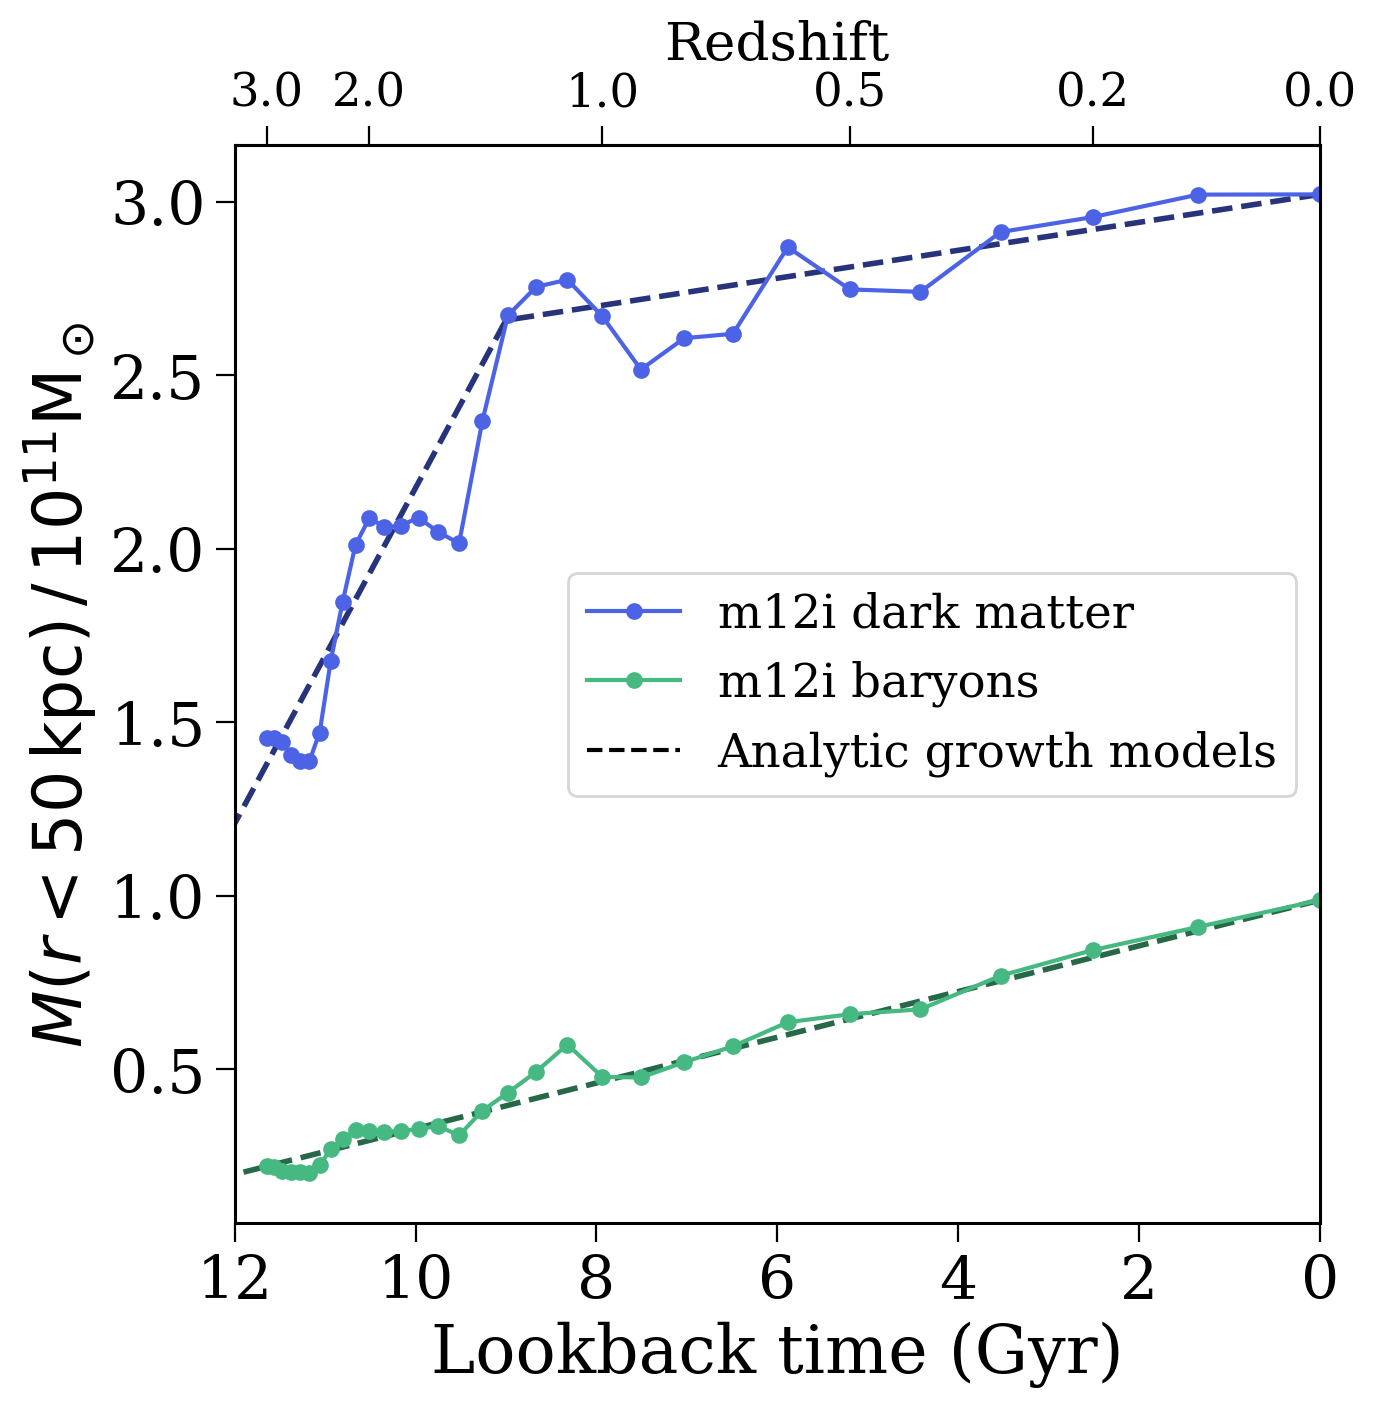

In [14]:
@np.vectorize
def dm_mass_growth_at_t(t):
    if t < 3:
        return (0.4 + (0.88 - 0.4) / 3 * t)
    else:
        return (0.88 + (1.0 - 0.88) / (12 - 3) * (t - 3))

def baryon_mass_growth_at_t(t):
    return (1 - 0.2) / 12 * t + 0.2

@np.vectorize
def dm_mass_growth_at_tau(tau):
    if tau > 9:
        return (2.32 - (0.88 - 0.4) / 3 * tau)
    else:
        return (1 - 12 / 900 * tau)

def baryon_mass_growth_at_tau(tau):
    return 0.8 / 12 * (12 - tau) + 0.2
    return 1 - 0.8 * tau

mass_scale = 1e11

radii = np.load(f"{path}/z_{0.00:.2f}.npz", allow_pickle=True)["radii"]
M_encs = np.array([np.load(f"{path}/z_{z:.2f}.npz", allow_pickle=True)["dm_M_enc"] for z in redshifts]) / mass_scale
M_encs_baryon = np.array([np.load(f"{path}/z_{z:.2f}.npz", allow_pickle=True)["baryon_M_enc"] for z in redshifts]) / mass_scale

fig, ax = plt.subplots(figsize=(7, 7))

r_idx = np.where(radii == 50)[0][0]
final_dm_mass = M_encs[0, r_idx] 
final_baryon_mass = M_encs_baryon[0, r_idx]
ax.plot(lookback_times, M_encs[:, r_idx], marker='o',
        label=f"m12i dark matter", color='#4c63e6',
        markersize=5)
ax.plot(lookback_times, M_encs_baryon[:, r_idx], marker='o',
        label=f"m12i baryons", color="#46b882", markersize=5)

time_knots = np.linspace(0, 12, 250) * u.Gyr
# dm_mass_growth = dm_mass_growth_at_t(12 - time_knots.to(u.Gyr).value)
dm_mass_growth = dm_mass_growth_at_tau(time_knots.to(u.Gyr).value)
baryonic_mass_growth = baryon_mass_growth_at_t(12 - time_knots.to(u.Gyr).value)
ax.plot(time_knots.value, dm_mass_growth * final_dm_mass, '--', lw=2, zorder=-1, color="#27347c")
ax.plot(time_knots.value, baryonic_mass_growth * final_baryon_mass, '--', lw=2, zorder=-1, color="#276849")
ax.set(
    xlabel="Lookback time (Gyr)",
    ylabel=r"$M(r < 50 {\rm \, kpc}) \, / \, 10^{11} {\rm M_\odot}$",
    xlim=(12, 0)
)
ax.plot([], [], 'k--',label="Analytic growth models")
ax.legend(loc='center right')

top_ax = ax.secondary_xaxis('top', functions=(lookback_to_redshift, redshift_to_lookback))
top_ax.set_xticks([0.0, 0.2, 0.5, 1.0, 2, 3])
top_ax.tick_params(which='major', labelsize=0.7*fs)
top_ax.set_xlabel("Redshift", fontsize=0.8*fs)

plt.savefig("../plots/m12i_mass_growth.pdf", format='pdf', bbox_inches='tight')

plt.show()

# Exploratory analysis

## Test stuff with one snapshot

In [27]:
redshift = 0.0
sim_dir = "/mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/"
part = gizmo.io.Read.read_snapshots(
    ["dark", "star", "gas"], "redshift", redshift, sim_dir, snapshot_directory="output"
)


# in utilities.simulation.Snapshot():
* reading:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/snapshot_times.txt

* input redshift = 0.0:  using snapshot index = 600, redshift = 0.000


# in gizmo_analysis.gizmo_io.Read():
* reading header from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/output/snapdir_600/snapshot_600.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 70514272 particles
    dark2     (id = 2): 5513331 particles
    gas       (id = 0): 57060074 particles
    star      (id = 4): 13976485 particles
    blackhole (id = 5): 0 particles

* reading the following
  species: ['dark', 'star', 'gas']

* reading particles from:
    snapshot_600.0.hdf5
    snapshot_600.1.hdf5
    snapshot_600.2.hdf5
    snapshot_600.3.hdf5

* reading cosmological parameters from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/initial_condition/ic_agora_m12i.conf

* checking sanity of particle properties




In [45]:
star_pos = part["star"].prop("host.distance.principal")

## Circularity stuff

In [3]:
all_pos = np.concatenate([part["star"].prop("host.distance.principal"),
                          part["dark"].prop("host.distance.principal"),
                          part["gas"].prop("host.distance.principal")])
all_mass = np.concatenate([part["star"]["mass"], part["dark"]["mass"], part["gas"]["mass"]])
all_R = (all_pos[:, 0]**2 + all_pos[:, 1]**2)**0.5

sort_idx = np.argsort(all_R)
r_sorted = all_R[sort_idx]
m_sorted = all_mass[sort_idx]

m_enc = np.cumsum(m_sorted)

R_grid = np.linspace(1e-5, 100.0, 5000)
indices = np.searchsorted(r_sorted, R_grid, side="right") - 1
indices = np.clip(indices, 0, len(m_enc) - 1)

M_grid = m_enc[indices]

v_circ = np.sqrt(const.G * M_grid * u.Msun / (R_grid * u.kpc)).to(u.km / u.s).value

get_v_circ = lambda r: np.interp(r, R_grid, v_circ)

In [4]:
def get_circularity(r, v):
    R = np.sqrt(r[:, 0] ** 2 + r[:, 1] ** 2)
    Lz = r[:, 0] * v[:, 1] - r[:, 1] * v[:, 0]
    
    vc = get_v_circ(R)
    circularity = Lz / (R * vc)

    return circularity

In [5]:
def get_pos_vel_m(part_type, circularity_thresh=0.0, dist_thresh=300.0):
    pos = part[part_type].prop("host.distance.principal")
    vel = part[part_type].prop("host.velocity.principal")
    mass = np.array(part[part_type]["mass"])

    d = np.linalg.norm(pos, axis=1)

    circularity = get_circularity(pos, vel)
    mask = (circularity > circularity_thresh) & (d < dist_thresh)

    return pos[mask], vel[mask], mass[mask]

In [21]:
star_pos, star_vel, star_mass = get_pos_vel_m("star", circularity_thresh=0.5, dist_thresh=50.0)

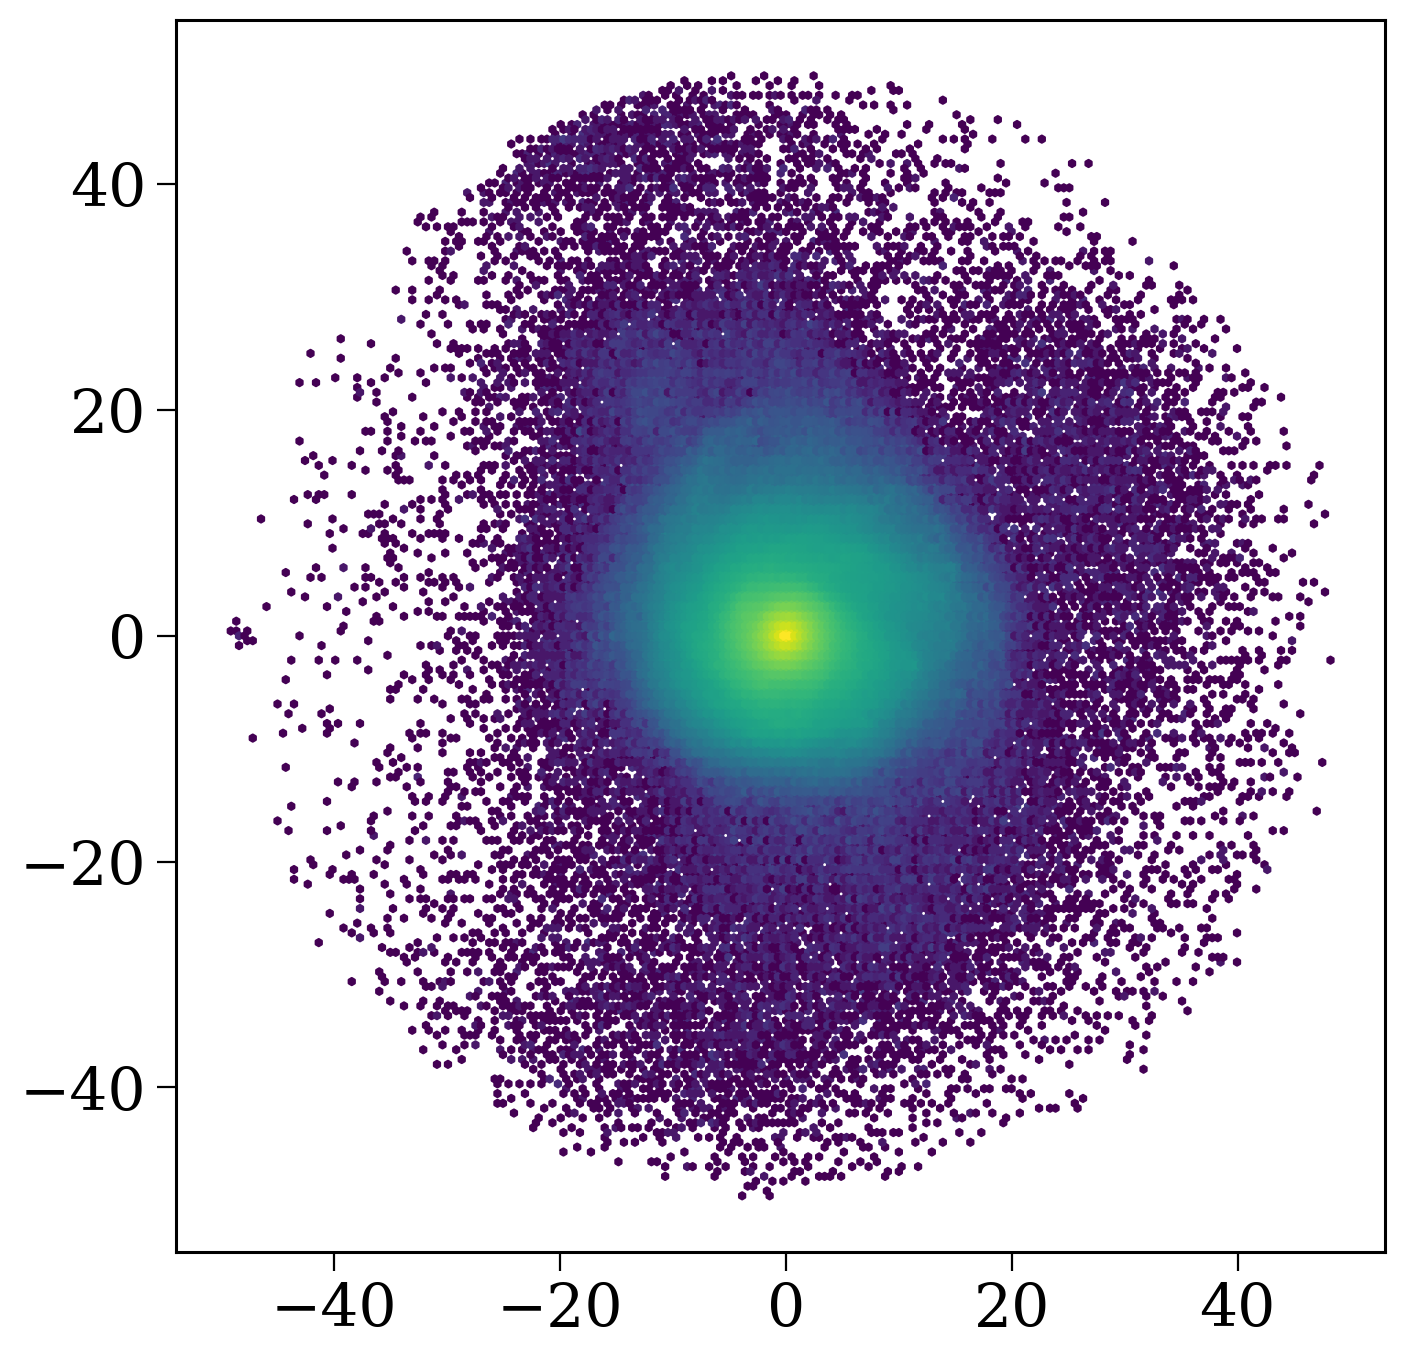

In [22]:
plt.hexbin(star_pos[:, 0], star_pos[:, 1], gridsize=200, cmap="viridis", mincnt=1, bins="log")
plt.gca().set_aspect("equal")

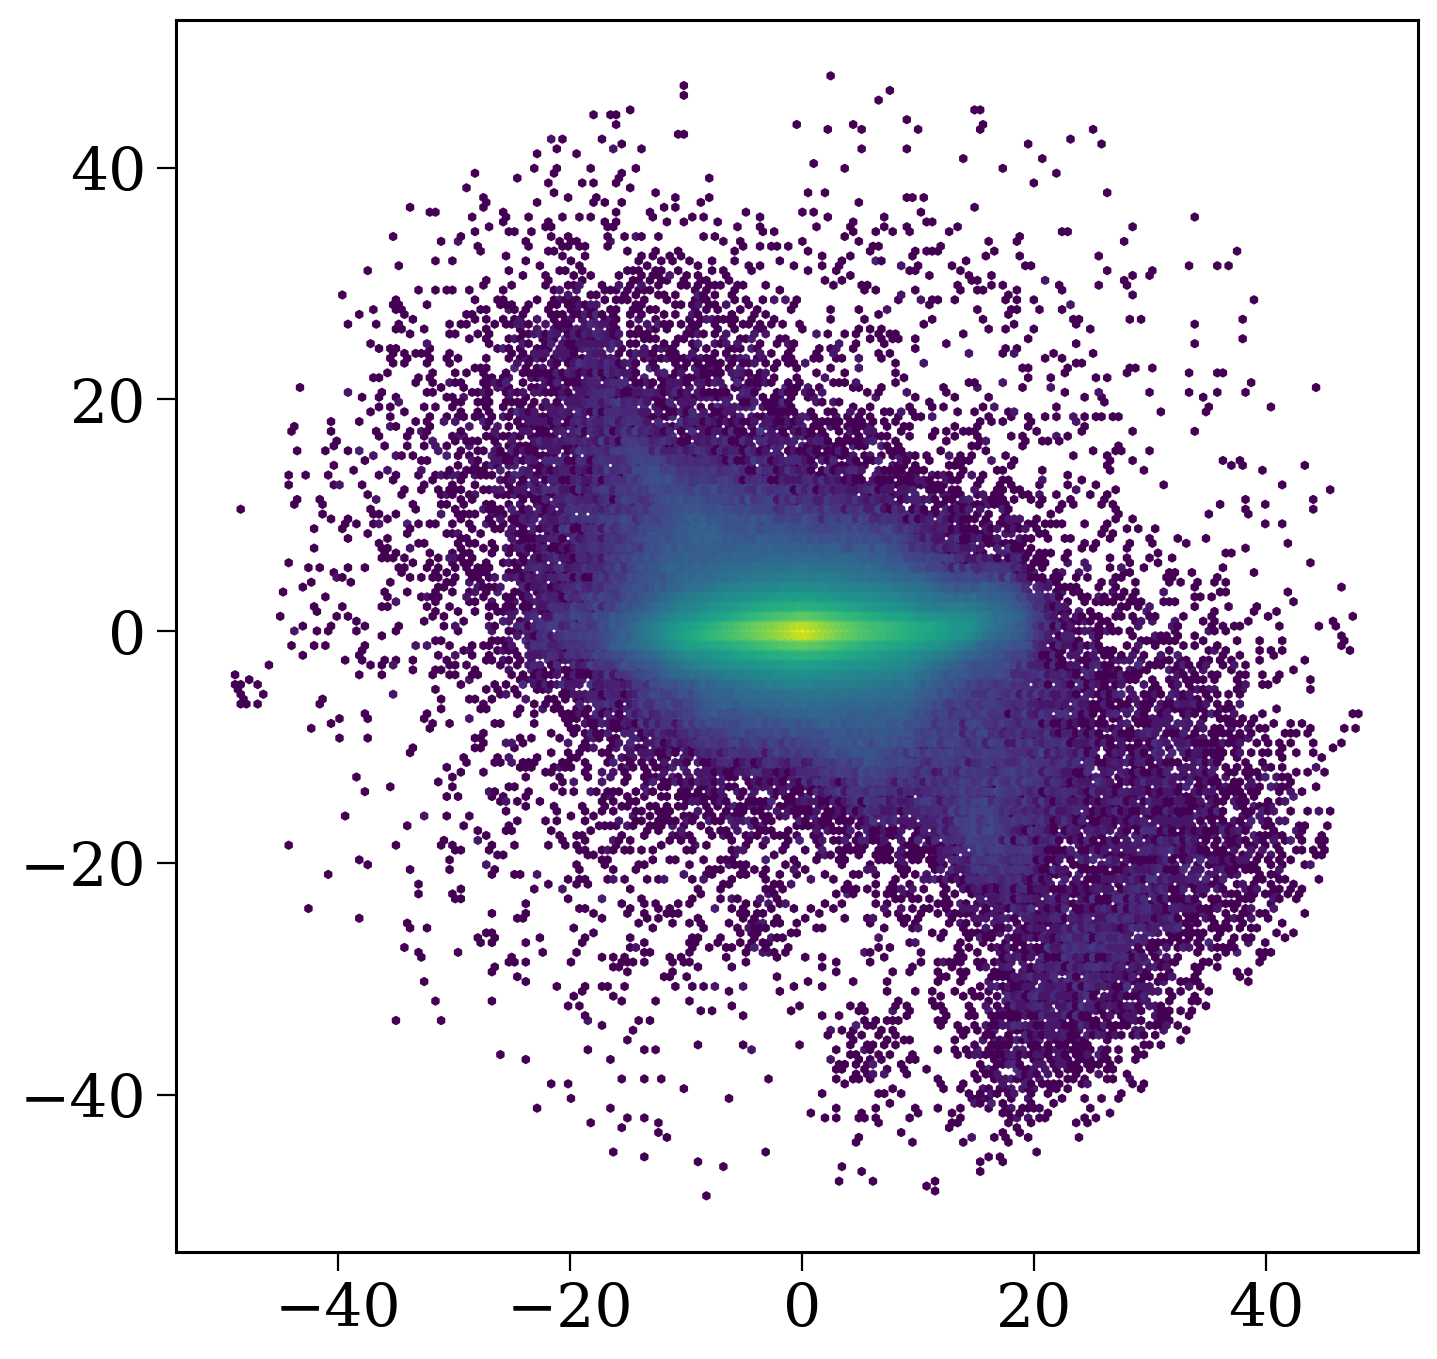

In [23]:
plt.hexbin(star_pos[:, 0], star_pos[:, 2], gridsize=200, cmap="viridis", mincnt=1, bins="log")
plt.gca().set_aspect("equal")

In [87]:
star_circularity = get_circularity(star_pos, star_vel)

## Density stuff

In [ ]:
R = np.sqrt(star_pos[:, 0]**2 + star_pos[:, 1]**2)
z = star_pos[:, 2]

Rbins = np.linspace(1, 30, 100)
zbins = np.linspace(-5, 5, 101)
H, xe, ye = np.histogram2d(R, z, bins=(Rbins, zbins), weights=star_mass)
Rbinc = 0.5 * (Rbins[1:] + Rbins[:-1])
zbinc = 0.5 * (zbins[1:] + zbins[:-1])

# volume factor
V = 2 * np.pi * (Rbins[1:]**2 - Rbins[:-1]**2)[:, None] * (zbins[1:] - zbins[:-1])[None, :]

# adjust density by volume
dens = H / V

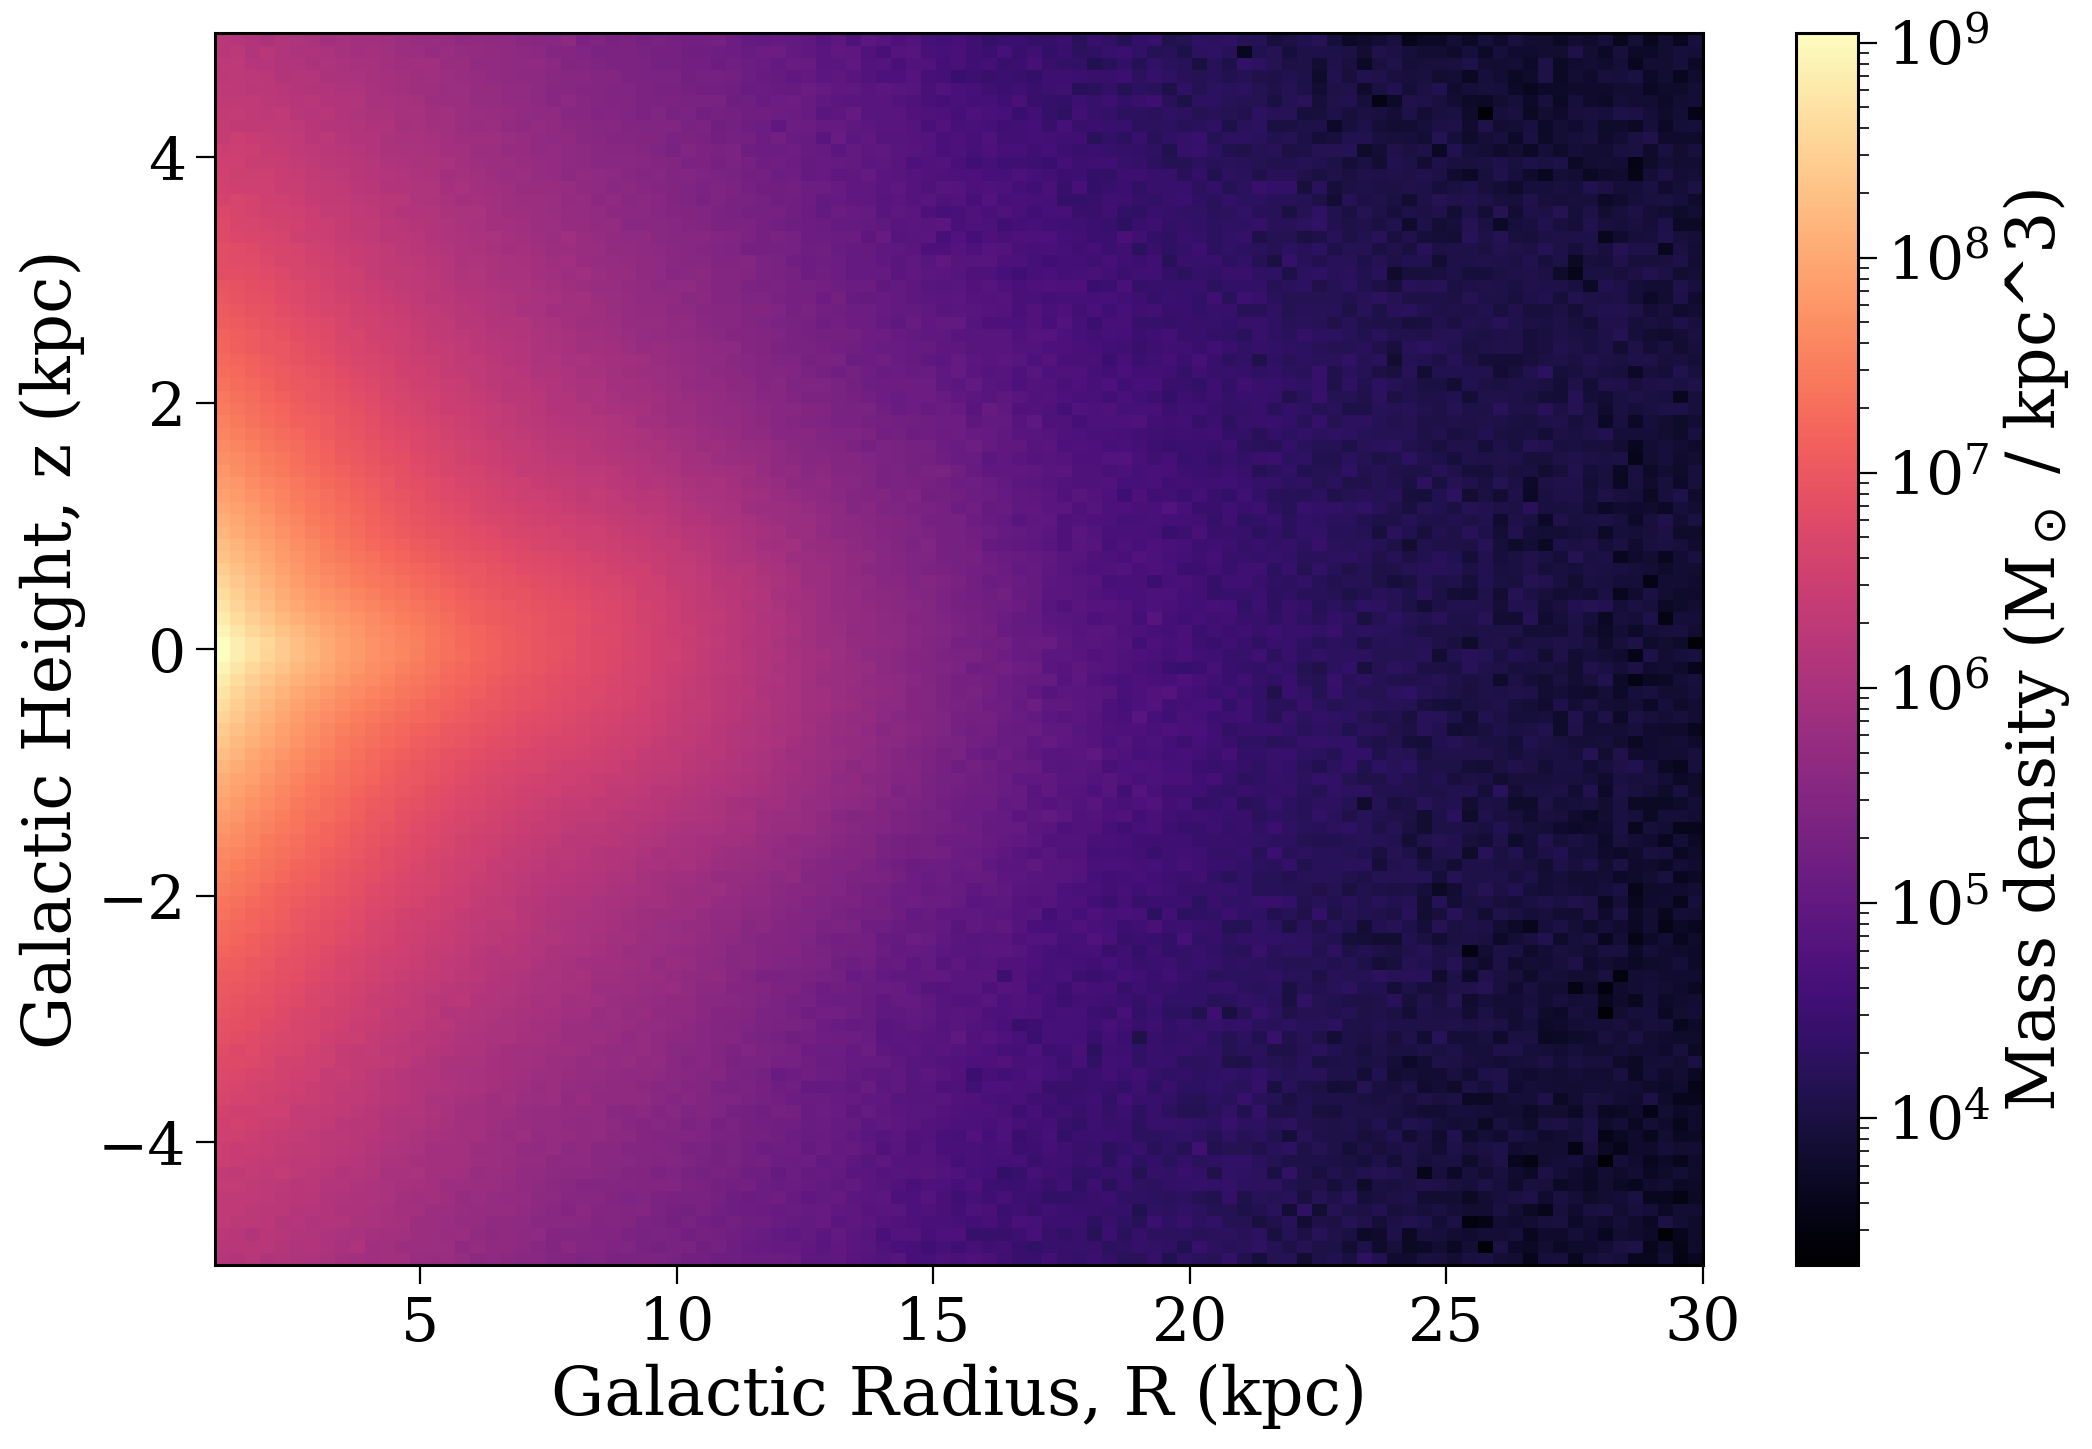

In [10]:
fig, ax = plt.subplots()

ax.pcolormesh(xe, ye, dens.T, norm=mpl.colors.LogNorm(), cmap='magma')
fig.colorbar(ax.collections[0], label="Mass density (M$_\odot$ / kpc^3)")

ax.set(
    xlabel='Galactic Radius, R (kpc)',
    ylabel='Galactic Height, z (kpc)',
)

plt.show()

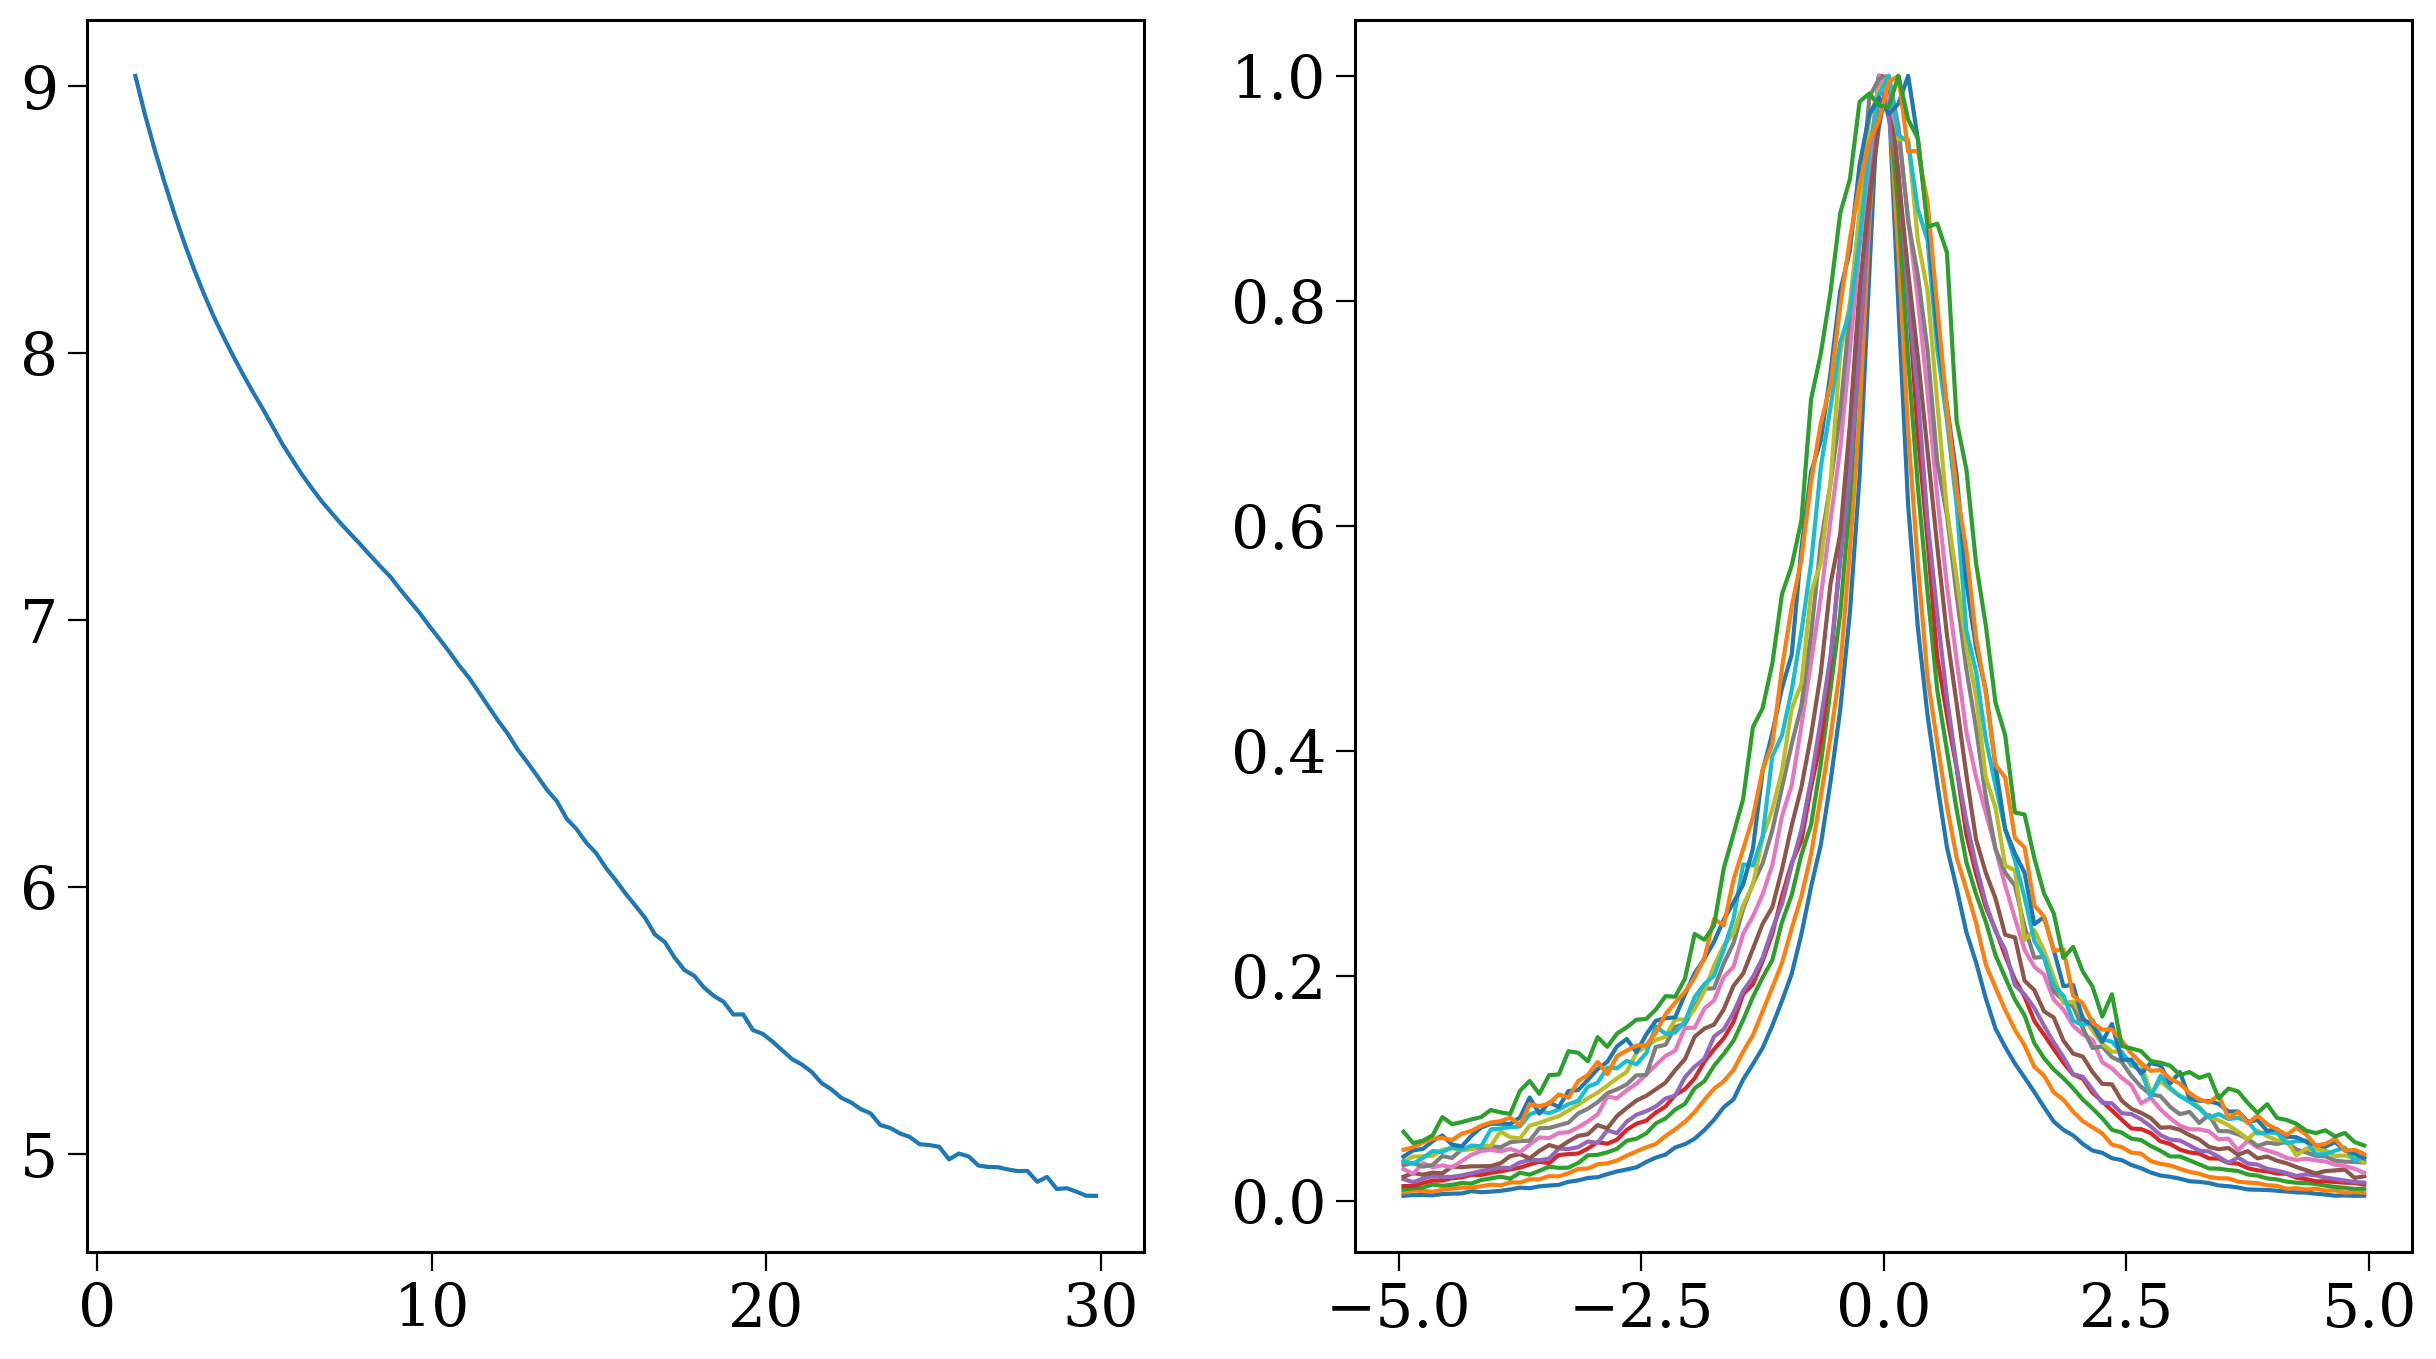

In [32]:
surf_mass_R = np.sum(dens, axis=1) * (ye[1] - ye[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].plot(Rbinc, np.log10(surf_mass_R))
# axes[0].set_yscale("log")

# axes[1].plot(zbinc, dens[8:50:2].T, marker="")``
for line in dens[4:30:2]:
    axes[1].plot(zbinc, line / line.max(), marker="")

In [82]:
cosmo.lookback_time([0, dddd])

<Quantity [ 0.        , 13.42018865] Gyr>

In [130]:
densities = np.array([np.load(f"{path}/z_{z:.2f}.npz", allow_pickle=True)["dens"] for z in redshifts])
xe = np.load(f"{path}/z_{0.00:.2f}.npz", allow_pickle=True)["xe"]
ye = np.load(f"{path}/z_{0.00:.2f}.npz", allow_pickle=True)["ye"]
Rbinc = 0.5 * (xe[1:] + xe[:-1])
zbinc = 0.5 * (ye[1:] + ye[:-1])

colours = plt.cm.viridis(np.linspace(0, 1, len(redshifts)))

/tmp/ipykernel_1345720/373347664.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.plot(Rbinc, np.log10(surf_mass_R), label=f"z={redshifts[i]:.2f}", color=colours[i], lw=3)


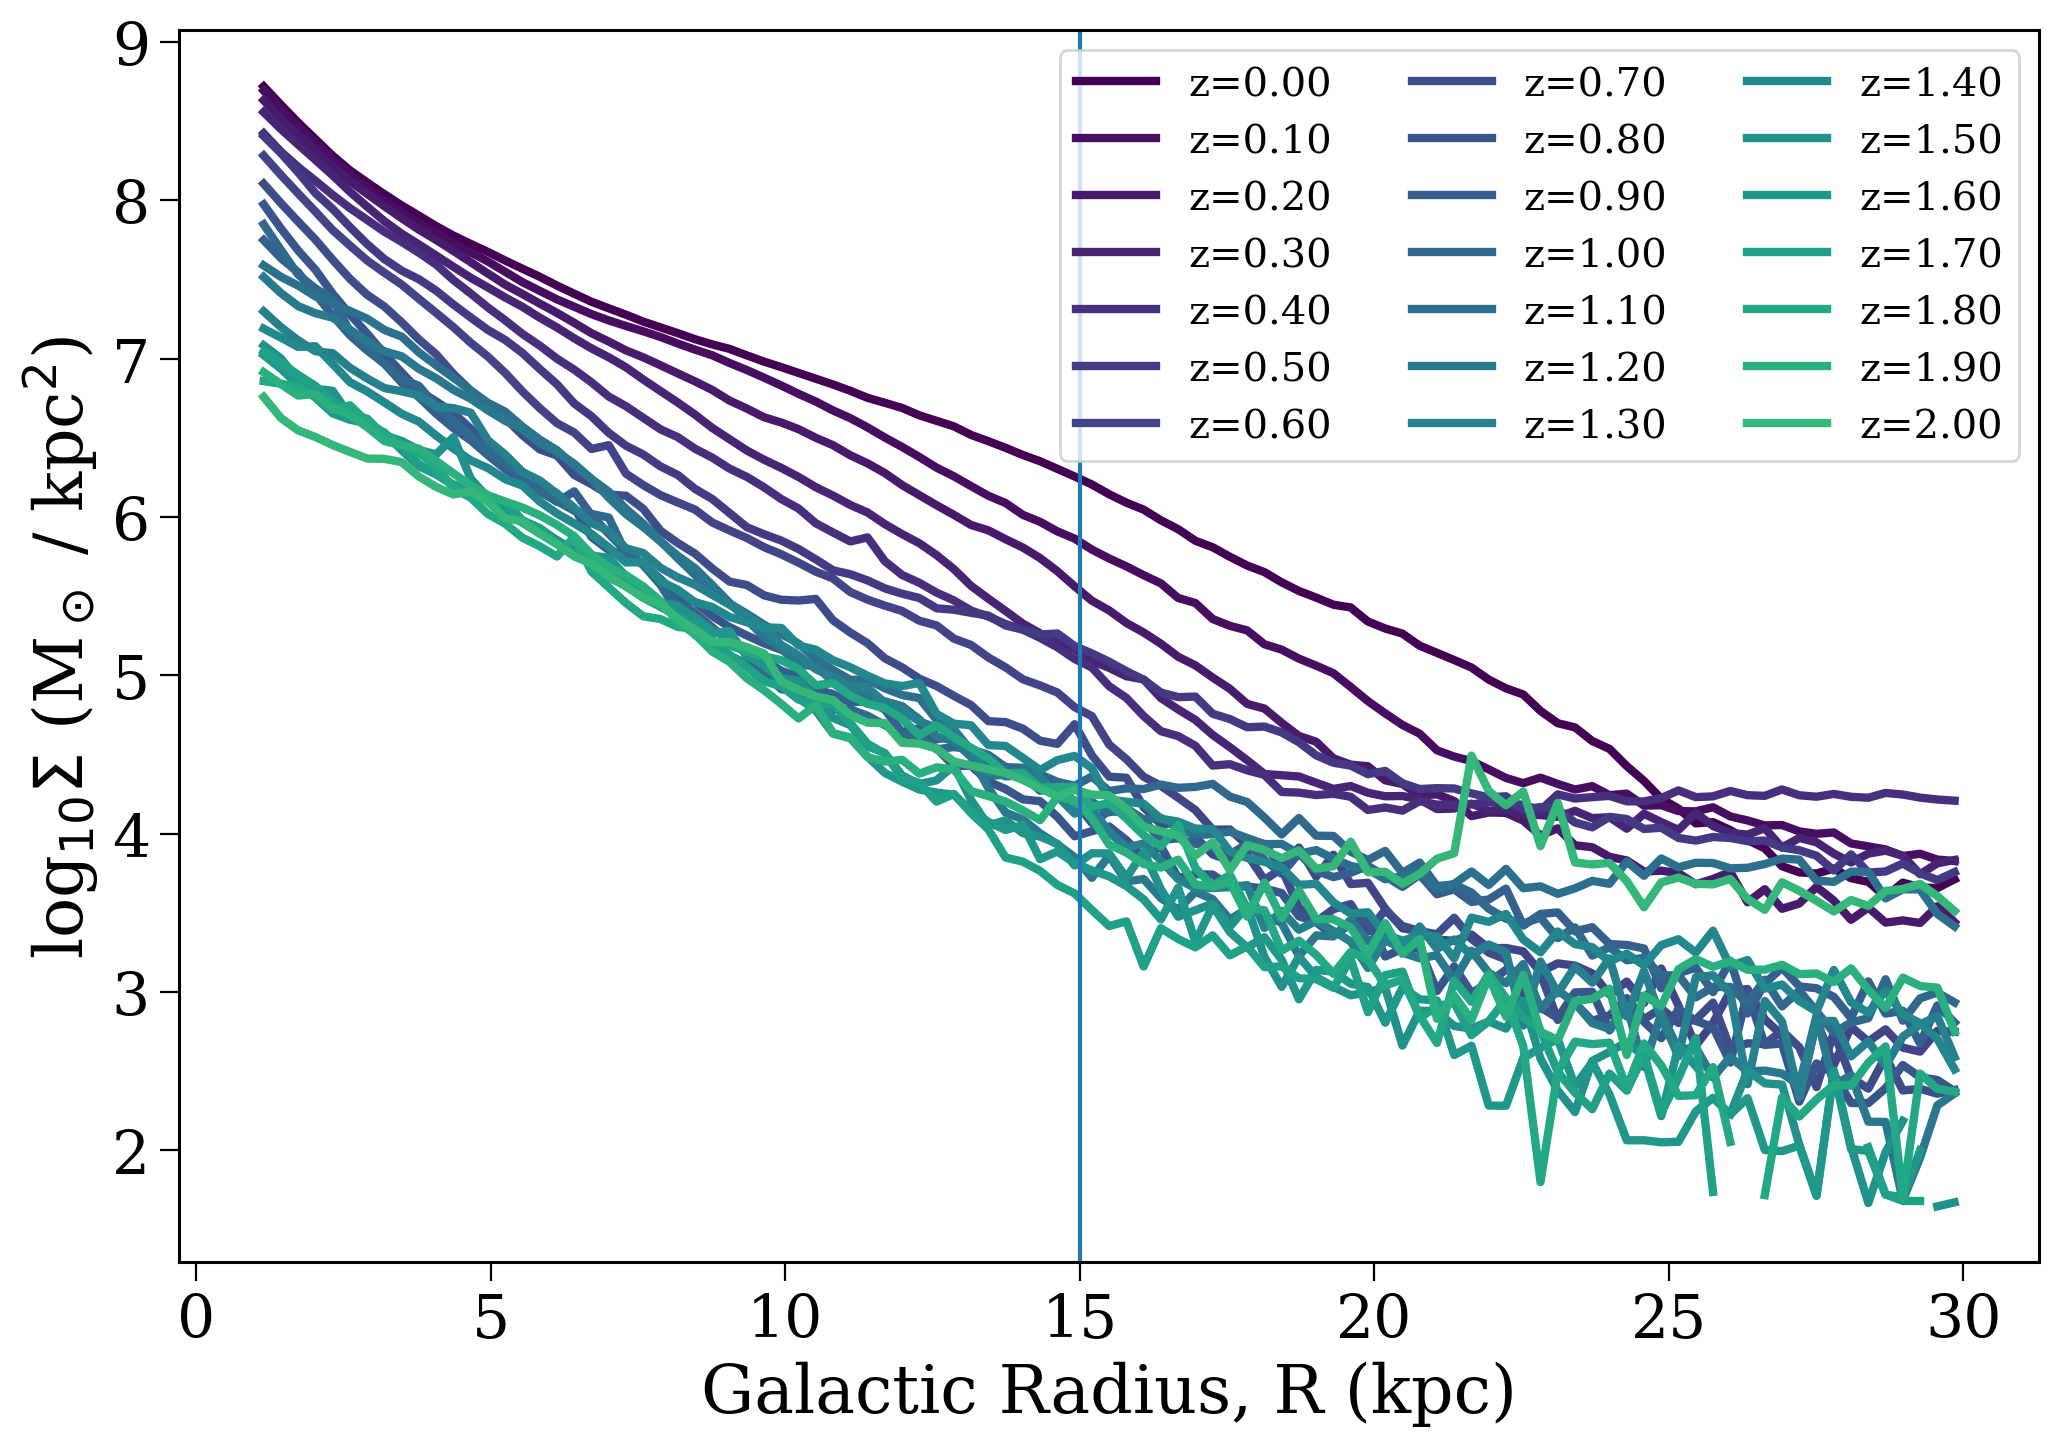

In [133]:
fig, ax = plt.subplots()

for i in range(0, len(redshifts)):
    if redshifts[i] > 2:
        continue
    surf_mass_R = np.sum(densities[i], axis=1) * (ye[1] - ye[0])
    ax.plot(Rbinc, np.log10(surf_mass_R), label=f"z={redshifts[i]:.2f}", color=colours[i], lw=3)

ax.set(
    xlabel="Galactic Radius, R (kpc)",
    ylabel="log$_{10} \Sigma$ (M$_\odot$ / kpc$^2$)",
)

ax.axvline(15)

ax.legend(ncol=3, fontsize=0.6*fs)

plt.show()

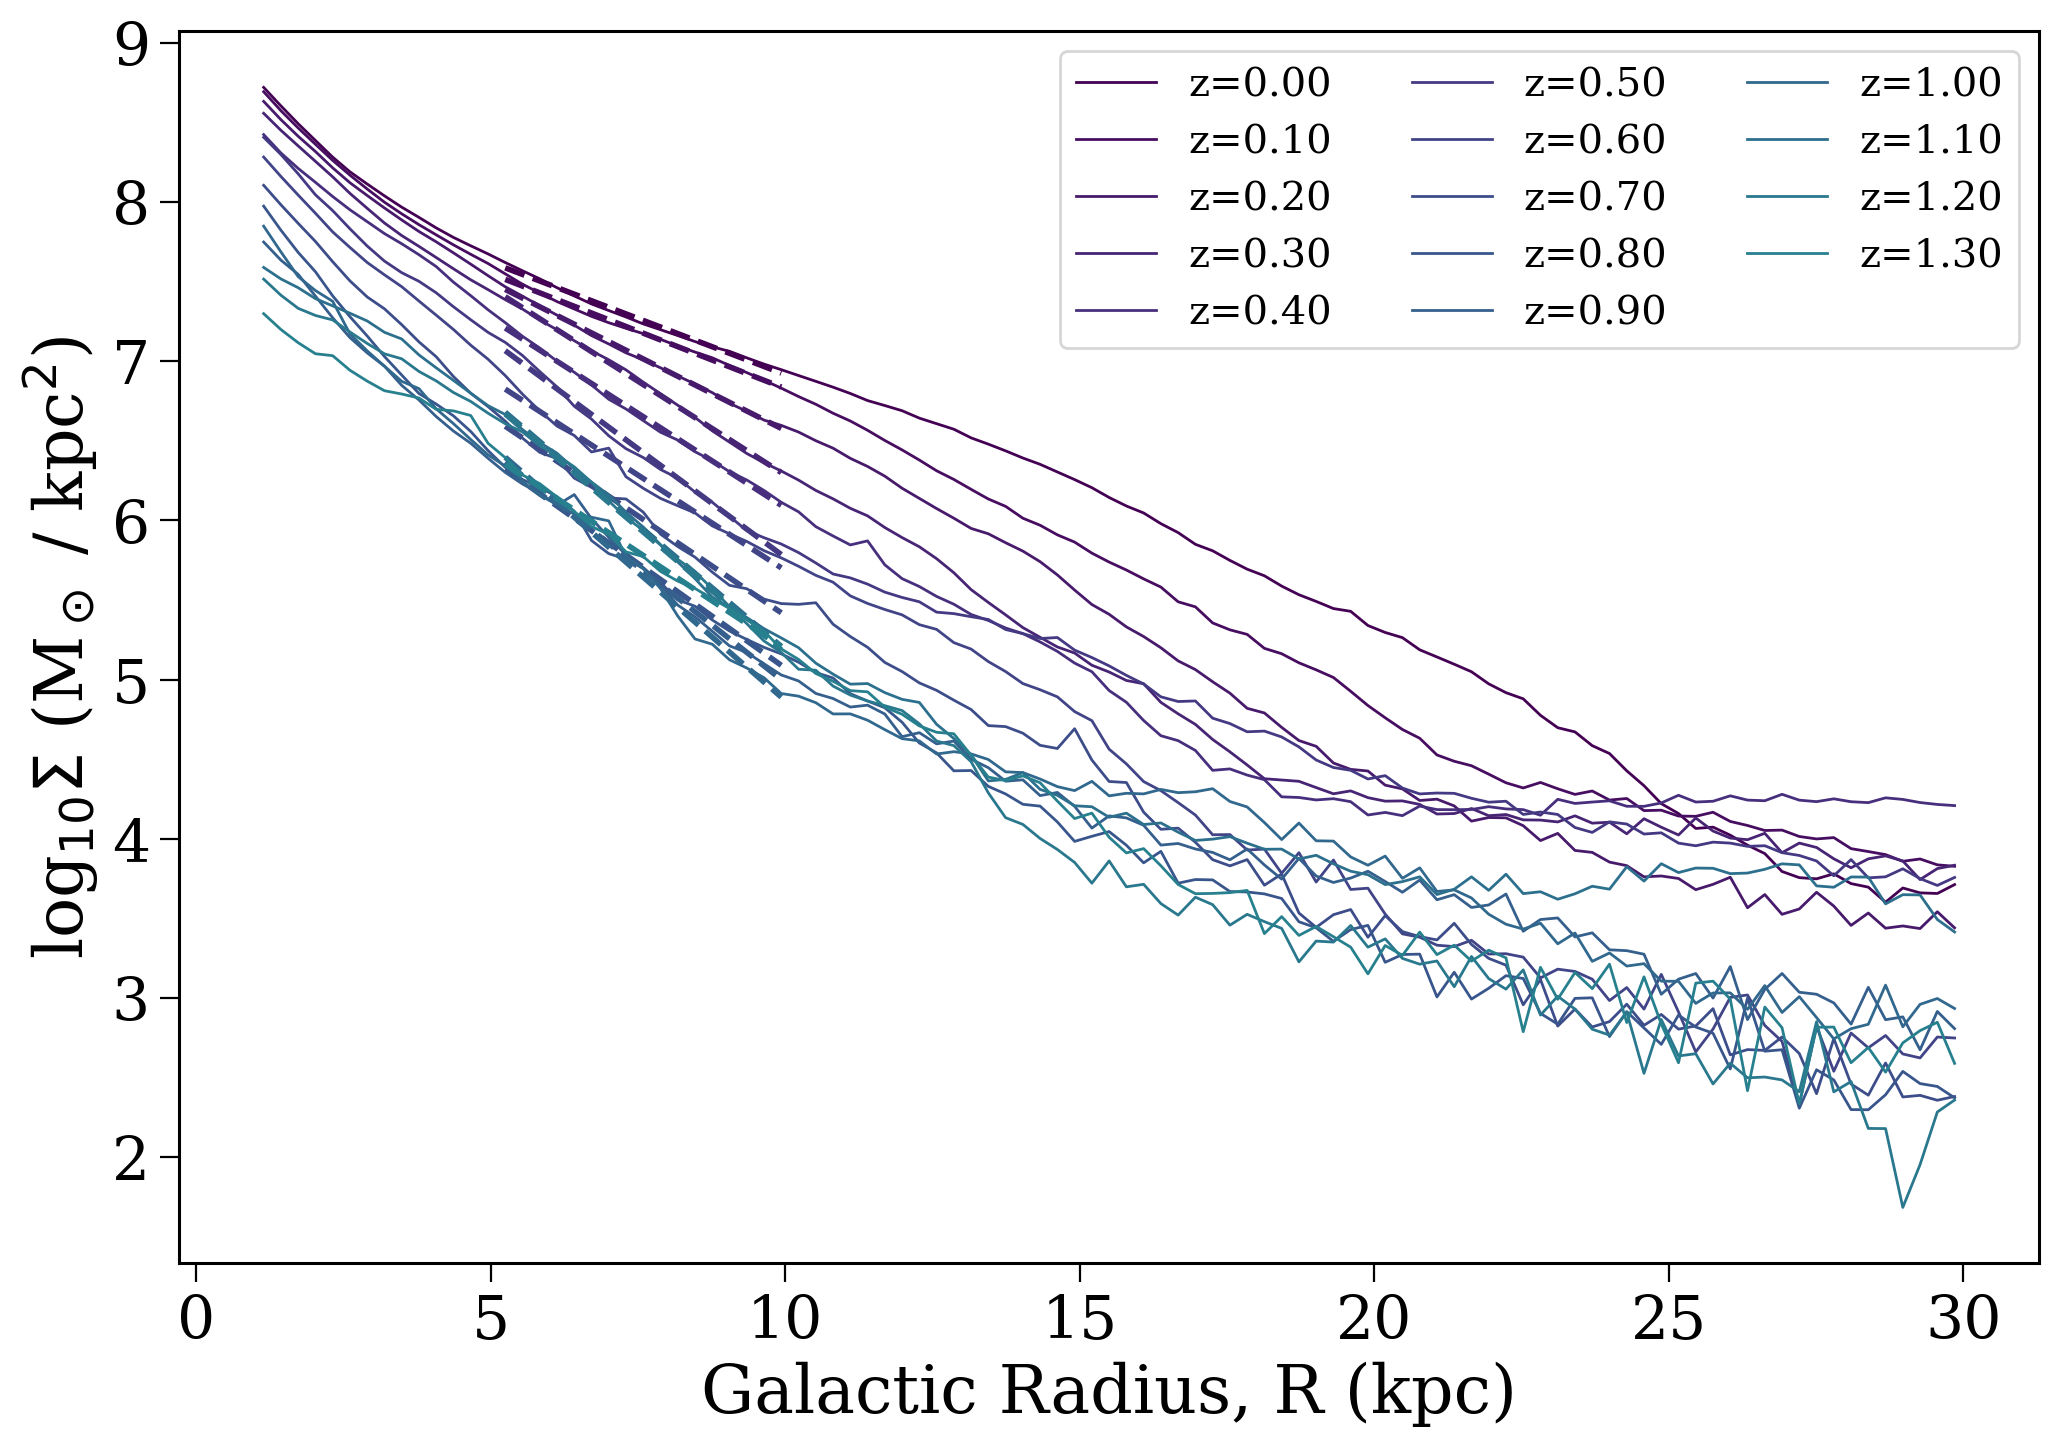

In [134]:
fig, ax = plt.subplots()

slopes = np.zeros(len(redshifts))

for i in range(0, len(redshifts)):
    if redshifts[i] > 1.4:
        continue
    surf_mass_R = np.sum(densities[i], axis=1) * (ye[1] - ye[0])
    ax.plot(Rbinc, np.log10(surf_mass_R), label=f"z={redshifts[i]:.2f}", color=colours[i], lw=1)

    # fit a linear line to surf_mass_R in the range of 5 to 15 kpc
    mask = (Rbinc >= 5) & (Rbinc <= 10)
    coeffs = np.polyfit(Rbinc[mask], np.log10(surf_mass_R[mask]), 1)
    fit_line = np.poly1d(coeffs)(Rbinc[mask])
    ax.plot(Rbinc[mask], fit_line, linestyle='--', color=colours[i], lw=2)

    slopes[i] = coeffs[0]

ax.set(
    xlabel="Galactic Radius, R (kpc)",
    ylabel="log$_{10} \Sigma$ (M$_\odot$ / kpc$^2$)",
)

ax.legend(ncol=3, fontsize=0.6*fs)

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


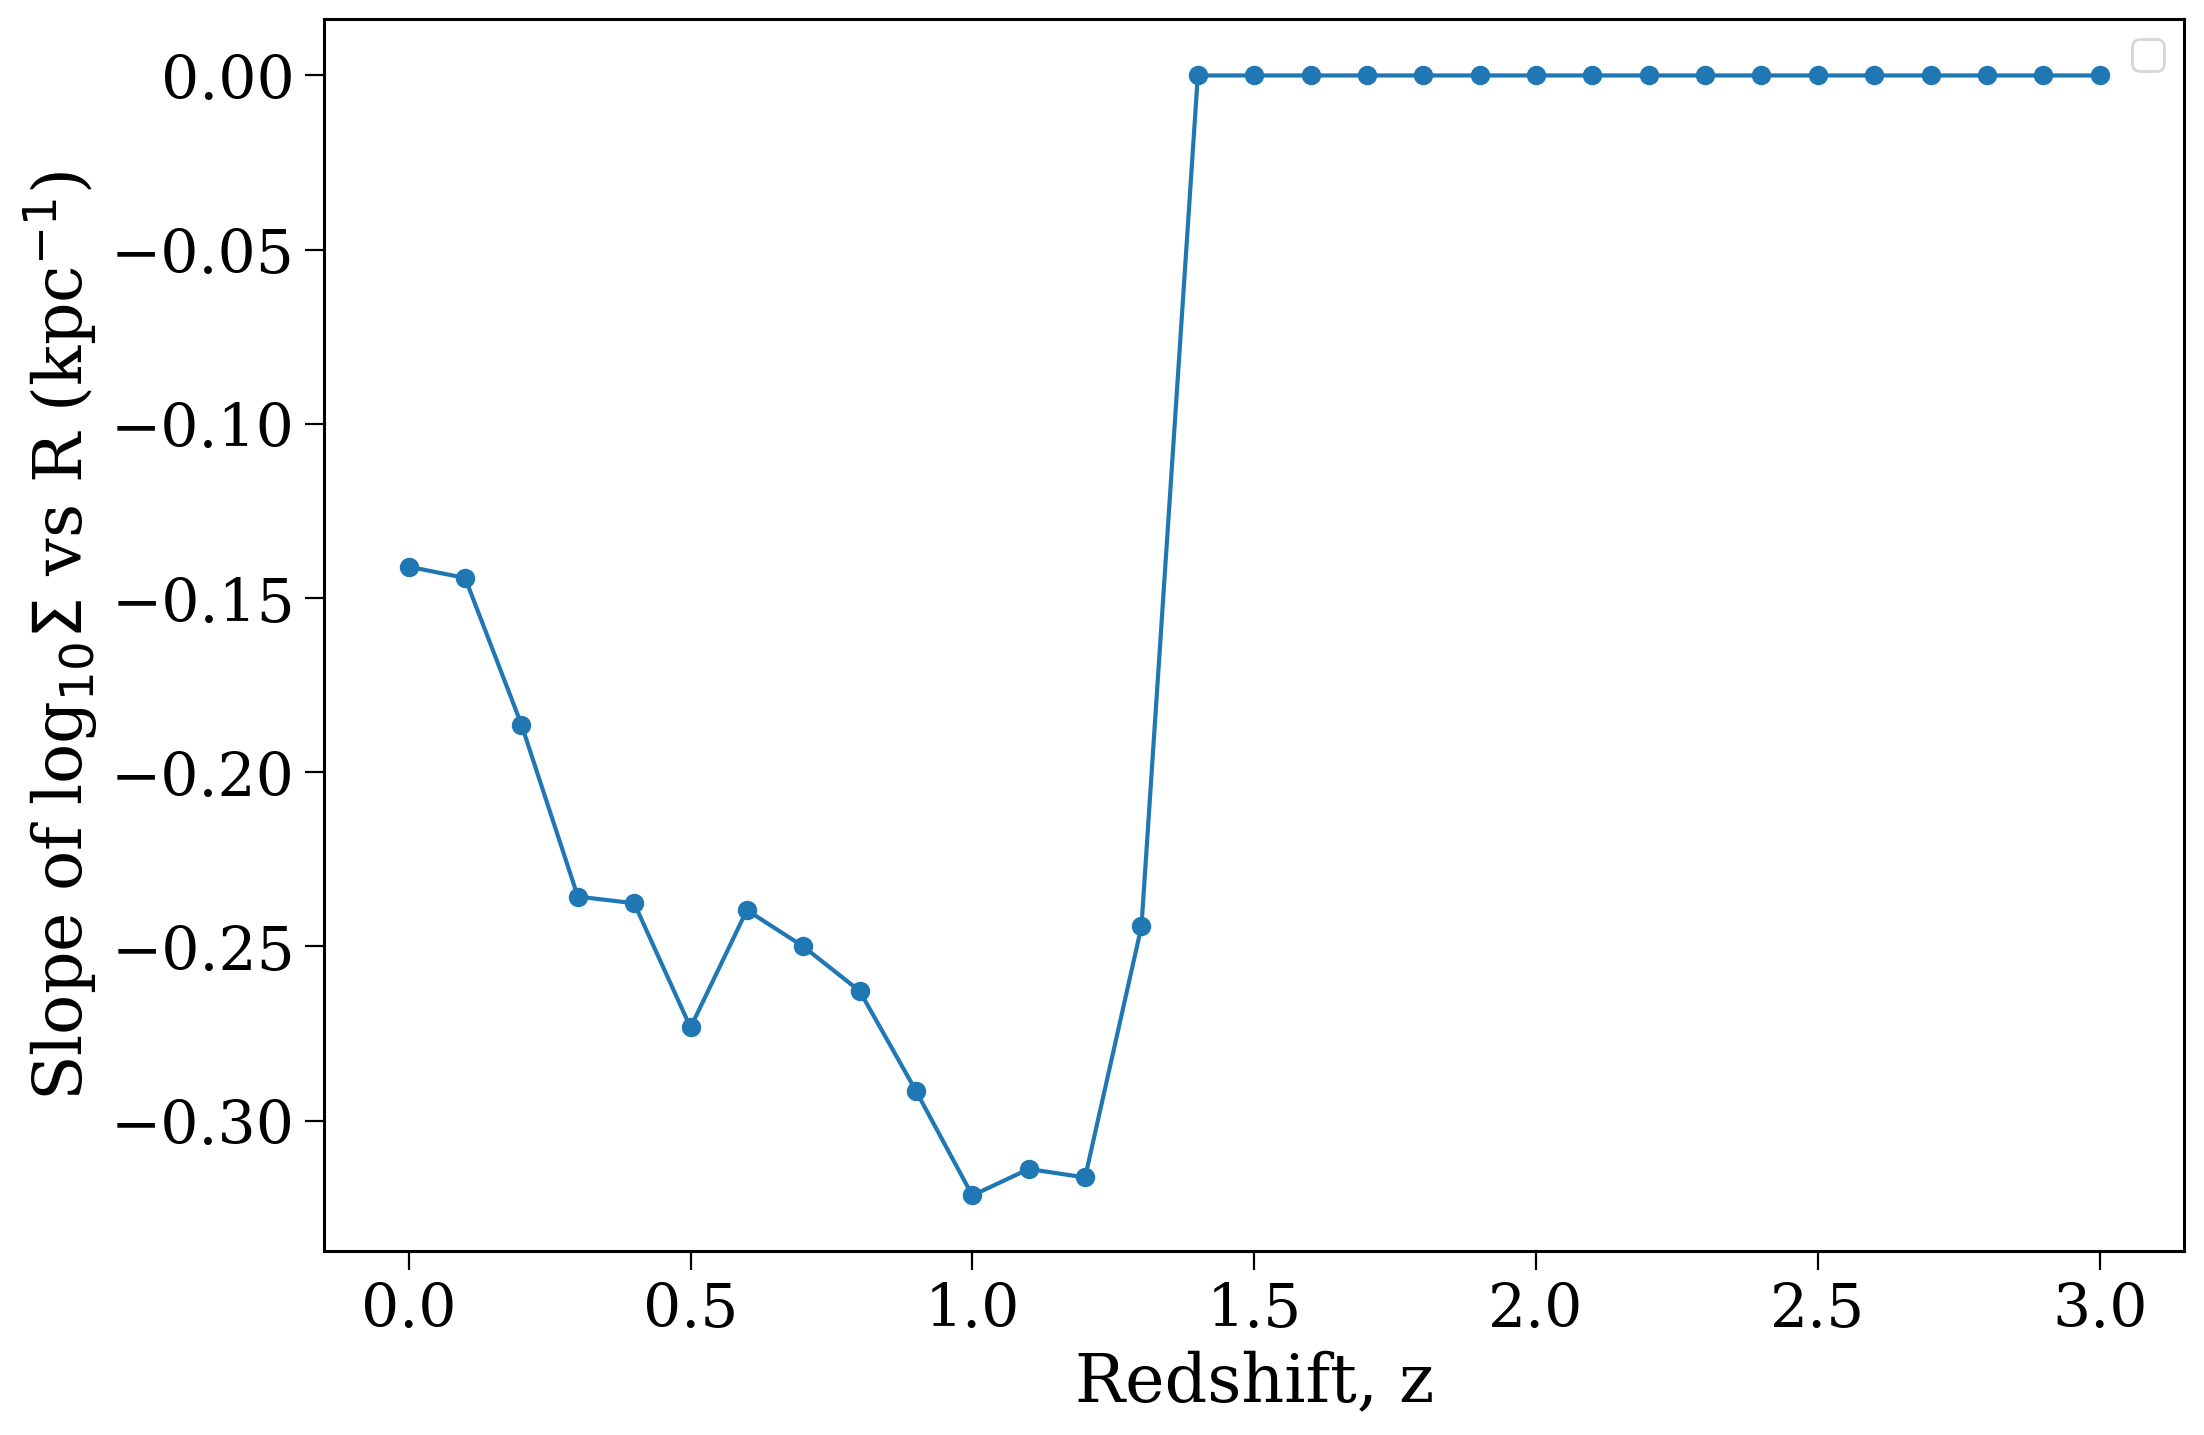

/tmp/ipykernel_1345720/3805636915.py:16: RuntimeWarning: divide by zero encountered in divide
  ax.plot(redshifts, -1/slopes, marker='o')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


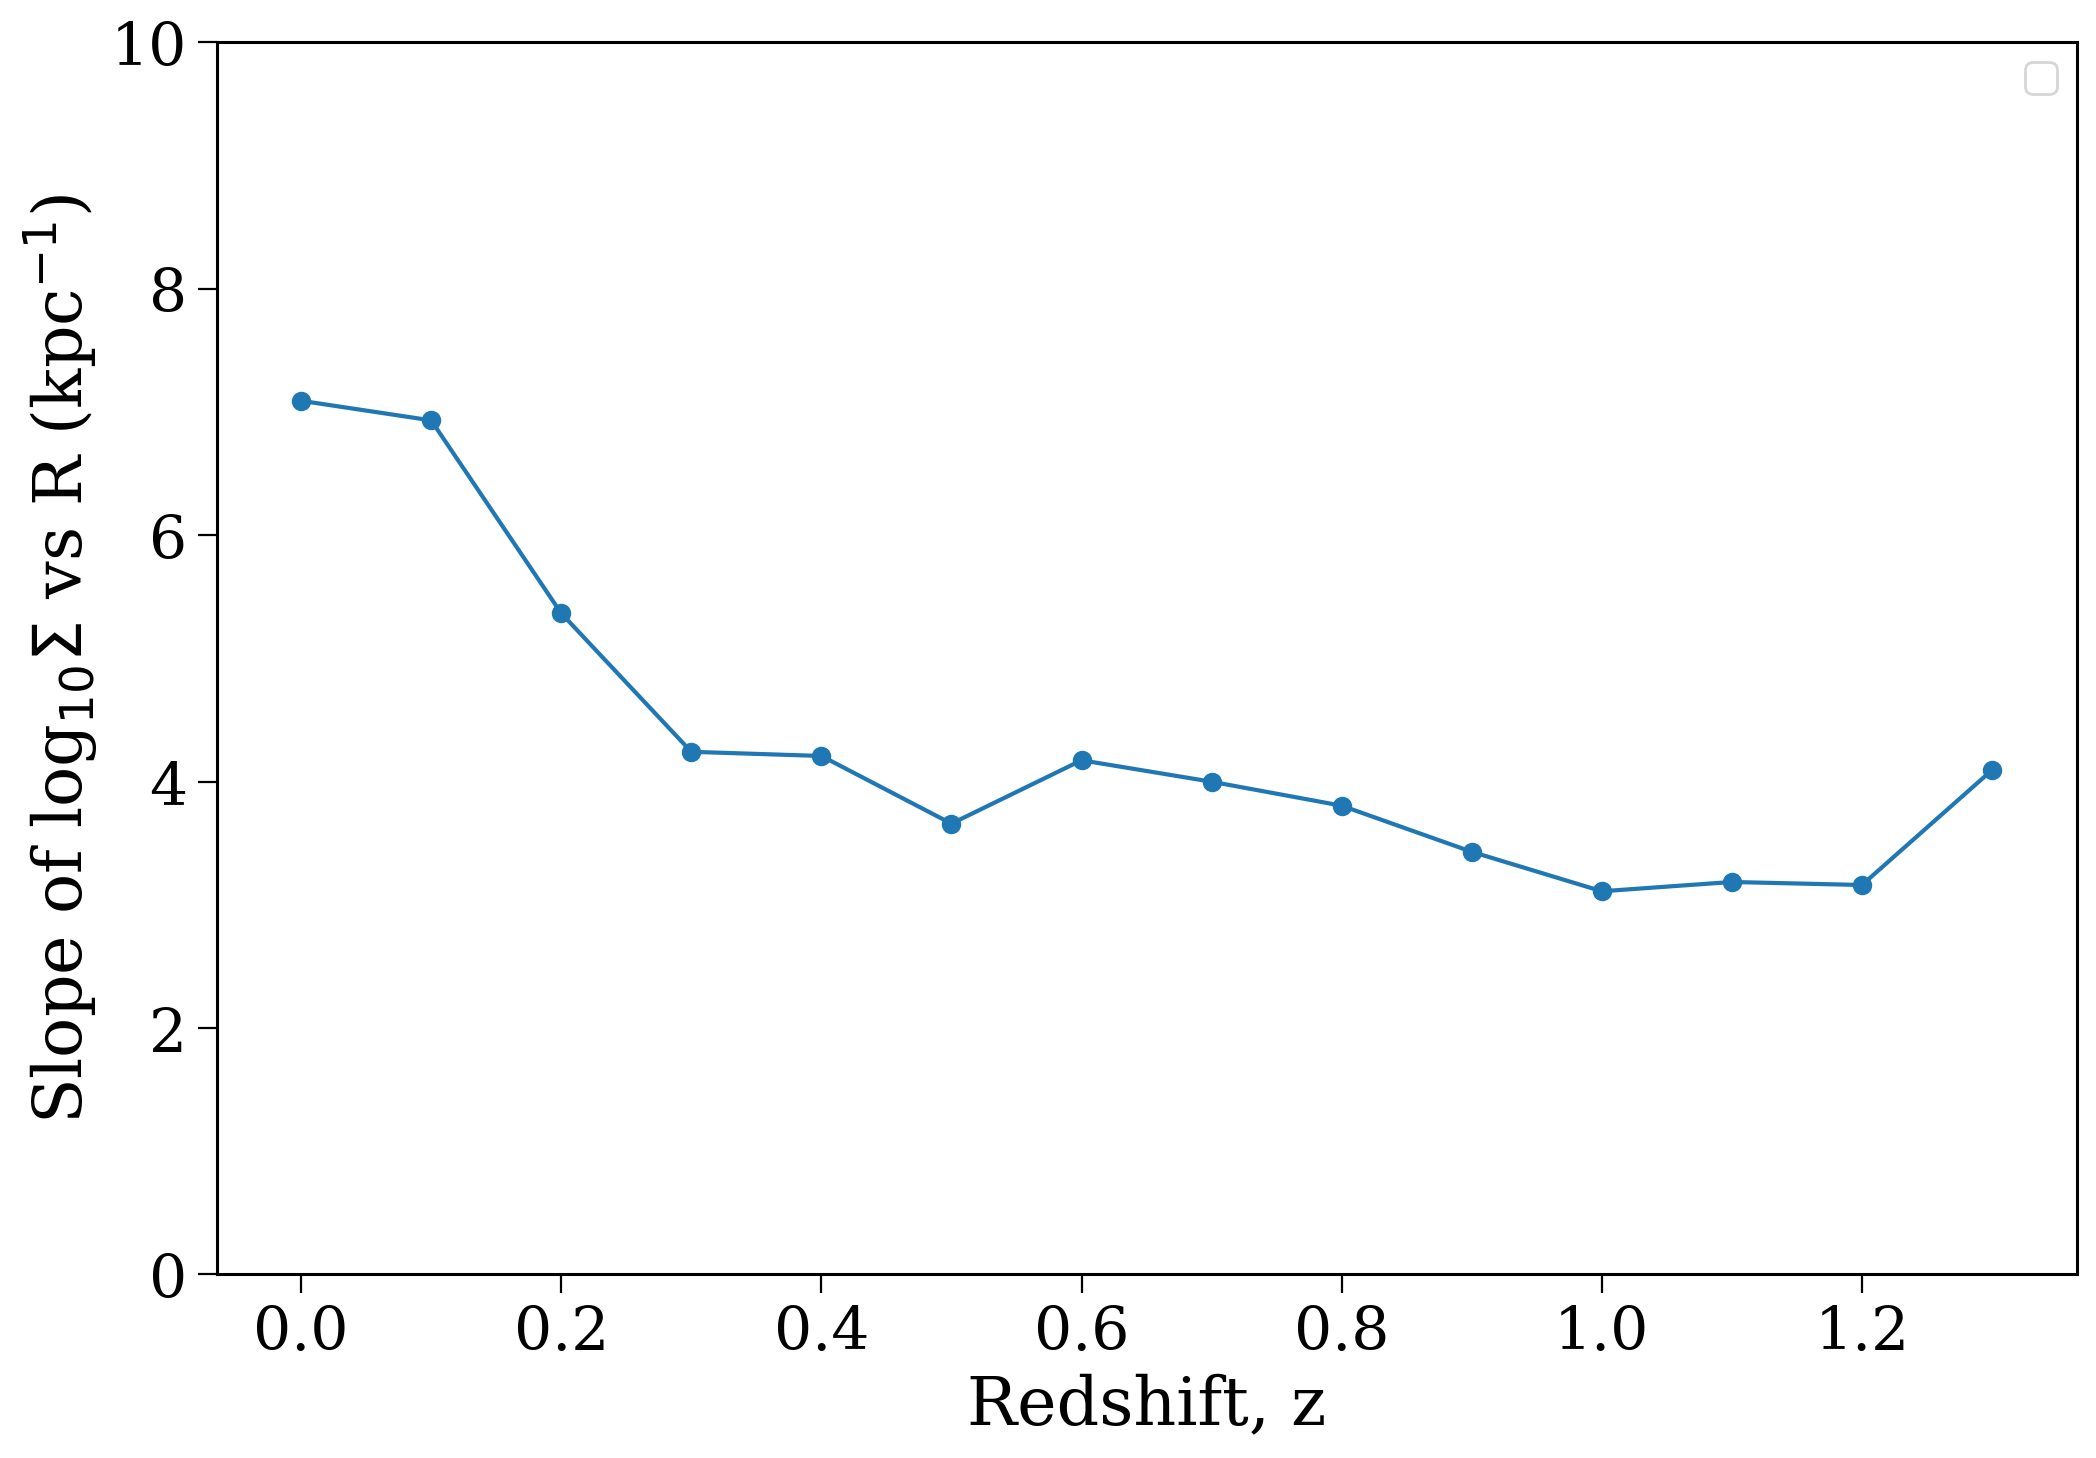

In [135]:
fig, ax = plt.subplots()

ax.plot(redshifts, slopes, marker='o')

ax.legend(ncol=3, fontsize=0.6*fs)

ax.set(
    xlabel="Redshift, z",
    ylabel="Slope of log$_{10} \Sigma$ vs R (kpc$^{-1}$)",
)

plt.show()

fig, ax = plt.subplots()

ax.plot(redshifts, -1/slopes, marker='o')

ax.legend(ncol=3, fontsize=0.6*fs)

ax.set(
    xlabel="Redshift, z",
    ylabel="Slope of log$_{10} \Sigma$ vs R (kpc$^{-1}$)",
    ylim=(0, 10)
)

plt.show()

# Work it back into a potential

In [39]:
import gala.potential as gp

In [40]:
static_mw = gp.MilkyWayPotential(version='v2')

time_knots = np.linspace(0, 12, 20) * u.Gyr

# use y = mx + c
# t < 3.5 Gyr: linear from (0, 0.45) to (3.5, 0.88)
# t >= 3.5 Gyr: linear from (3.5, 0.88) to (12, 1.0)
mass_at_knot = np.zeros_like(time_knots.value) * u.Msun
for i, t in enumerate(time_knots.value):
    if t < 3.5:
        mass_at_knot[i] = (0.45 + (0.88 - 0.45) / 3.5 * t) * u.Msun
    else:
        mass_at_knot[i] = (0.88 + (1.0 - 0.88) / (12 - 3.5) * (t - 3.5)) * u.Msun
mass_at_knot *= static_mw["halo"].parameters["m"].value

In [43]:
mw["disk"]

<MN3ExponentialDiskPotential: m=4.77e+10 solMass, h_R=2.60 kpc, h_z=0.30 kpc (kpc,Myr,solMass,rad)>

In [44]:
mw["bulge"]

<HernquistPotential: m=5.00e+09 solMass, c=1.00 kpc (kpc,Myr,solMass,rad)>

In [45]:
mw["nucleus"]

<HernquistPotential: m=1.81e+09 solMass, c=0.07 kpc (kpc,Myr,solMass,rad)>

In [54]:
static_mw["halo"]

<NFWPotential: m=5.54e+11 solMass, r_s=15.63 kpc, a=1.00 , b=1.00 , c=1.00  (kpc,Myr,solMass,rad)>

In [46]:
evolving_mw = gp.CCompositePotential(
    disk=gp.MN3ExponentialDiskPotential(
        m=4.77e10 * u.Msun,
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.HernquistPotential(
        m=5e9 * u.Msun,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.HernquistPotential(
        m=1.81e9 * u.Msun,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo=gp.TimeInterpolatedPotential(
        gp.NFWPotential,
        time_knots,
        m=mass_at_knot,
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

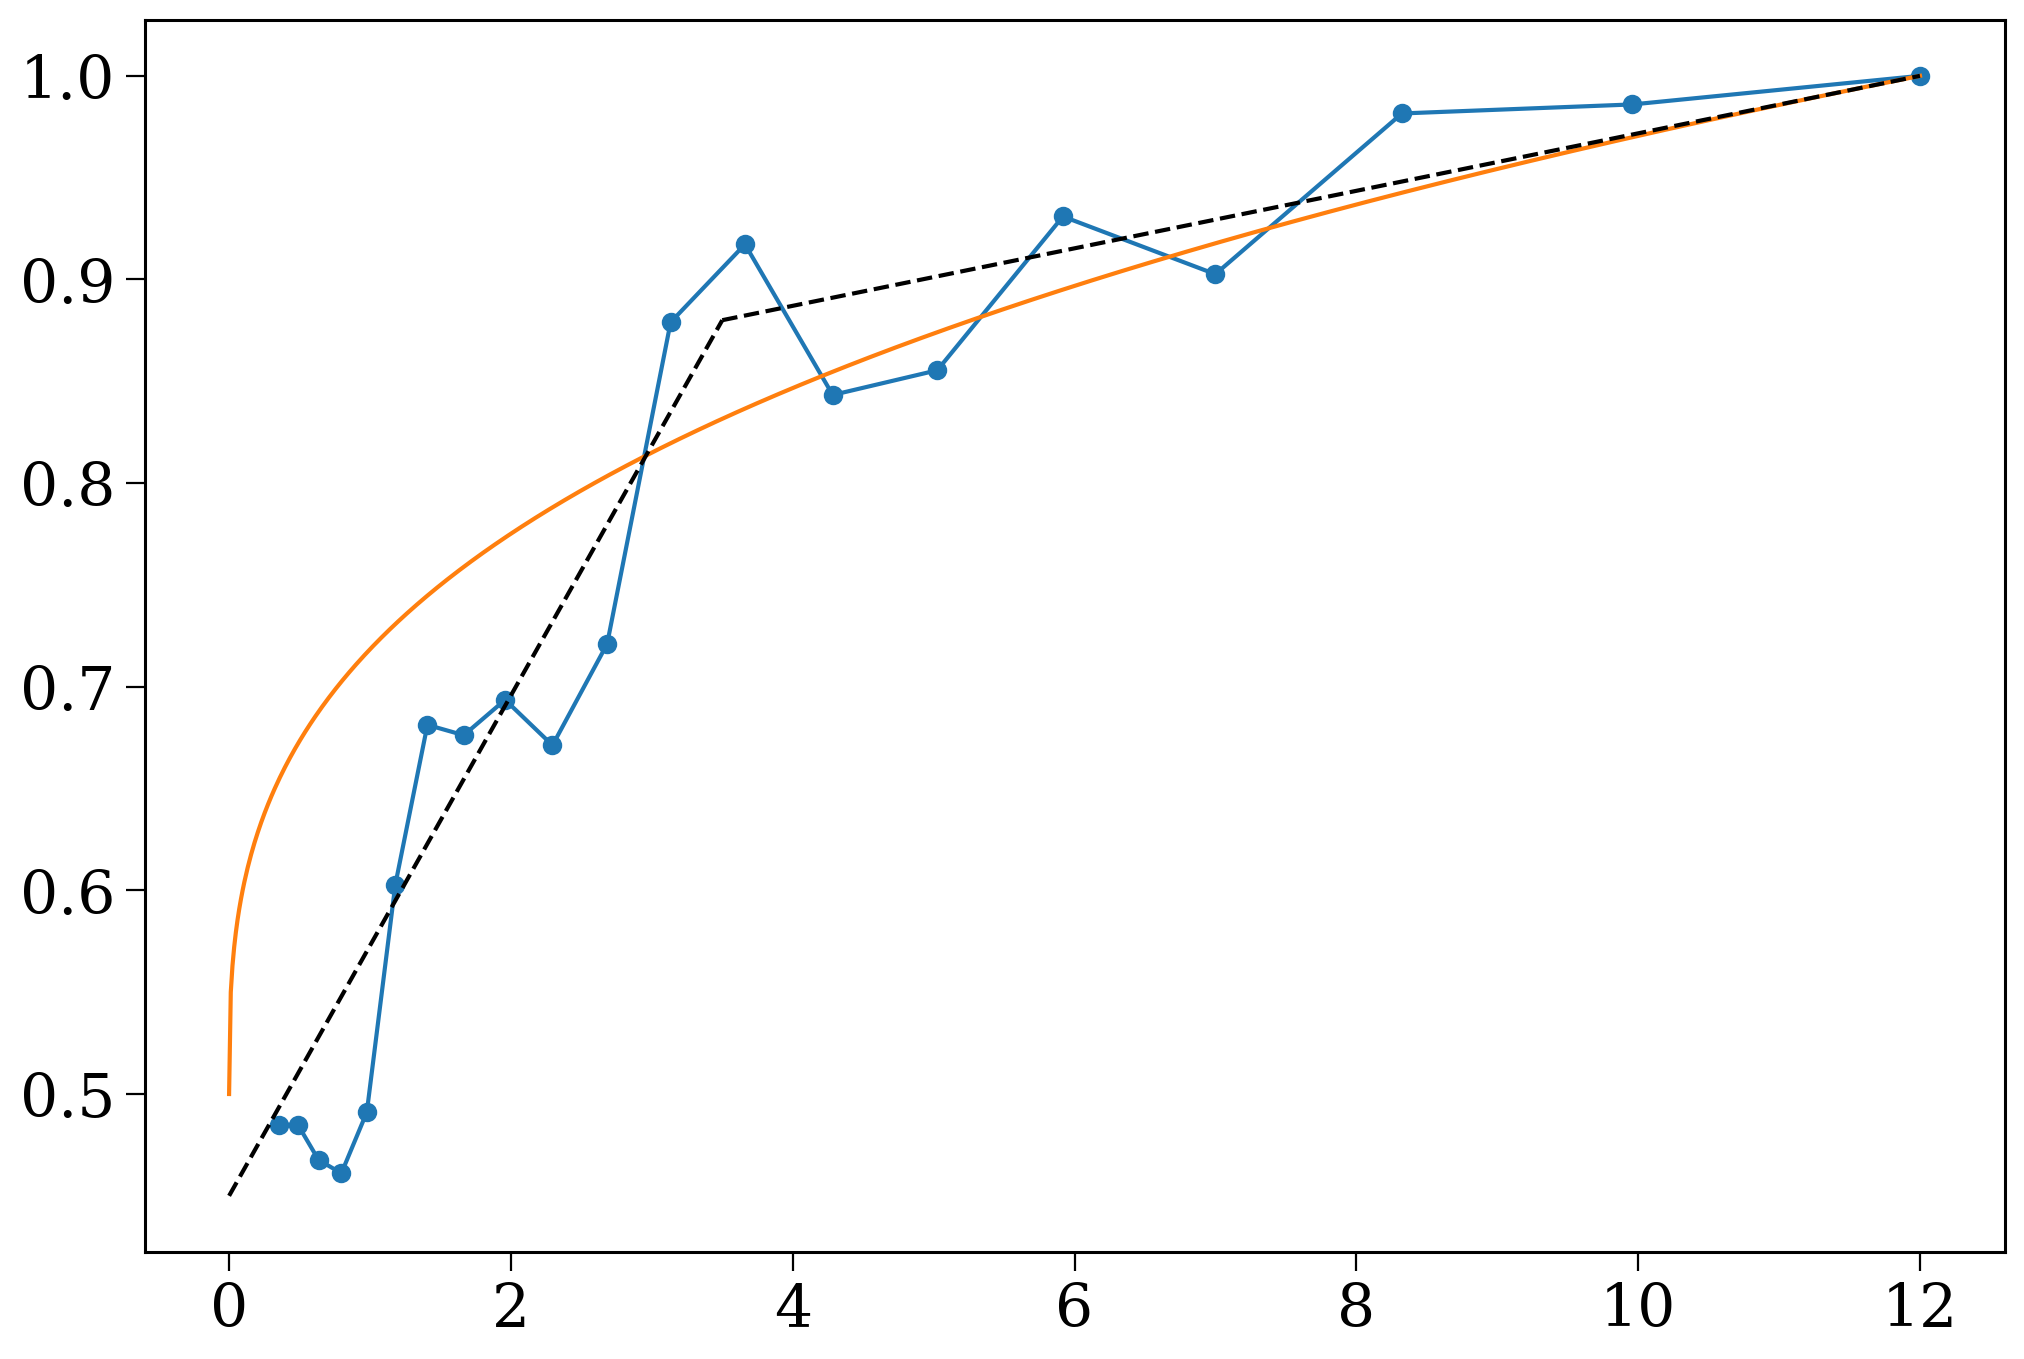

In [45]:
times = cosmo.lookback_time(redshifts).to(u.Gyr)
t_range = np.linspace(0, 12, 1000)
plt.plot(12 * u.Gyr - times, M_at_r / M_at_r.max(), marker='o')

powerlaw = 1/3
plt.plot(t_range, 0.5 + 0.5 * t_range**powerlaw / t_range[-1]**powerlaw)

plt.plot([0, 3.5], [0.45, 0.88], color='k', linestyle='--')
plt.plot([3.5, 12], [0.88, 1.0], color='k', linestyle='--')

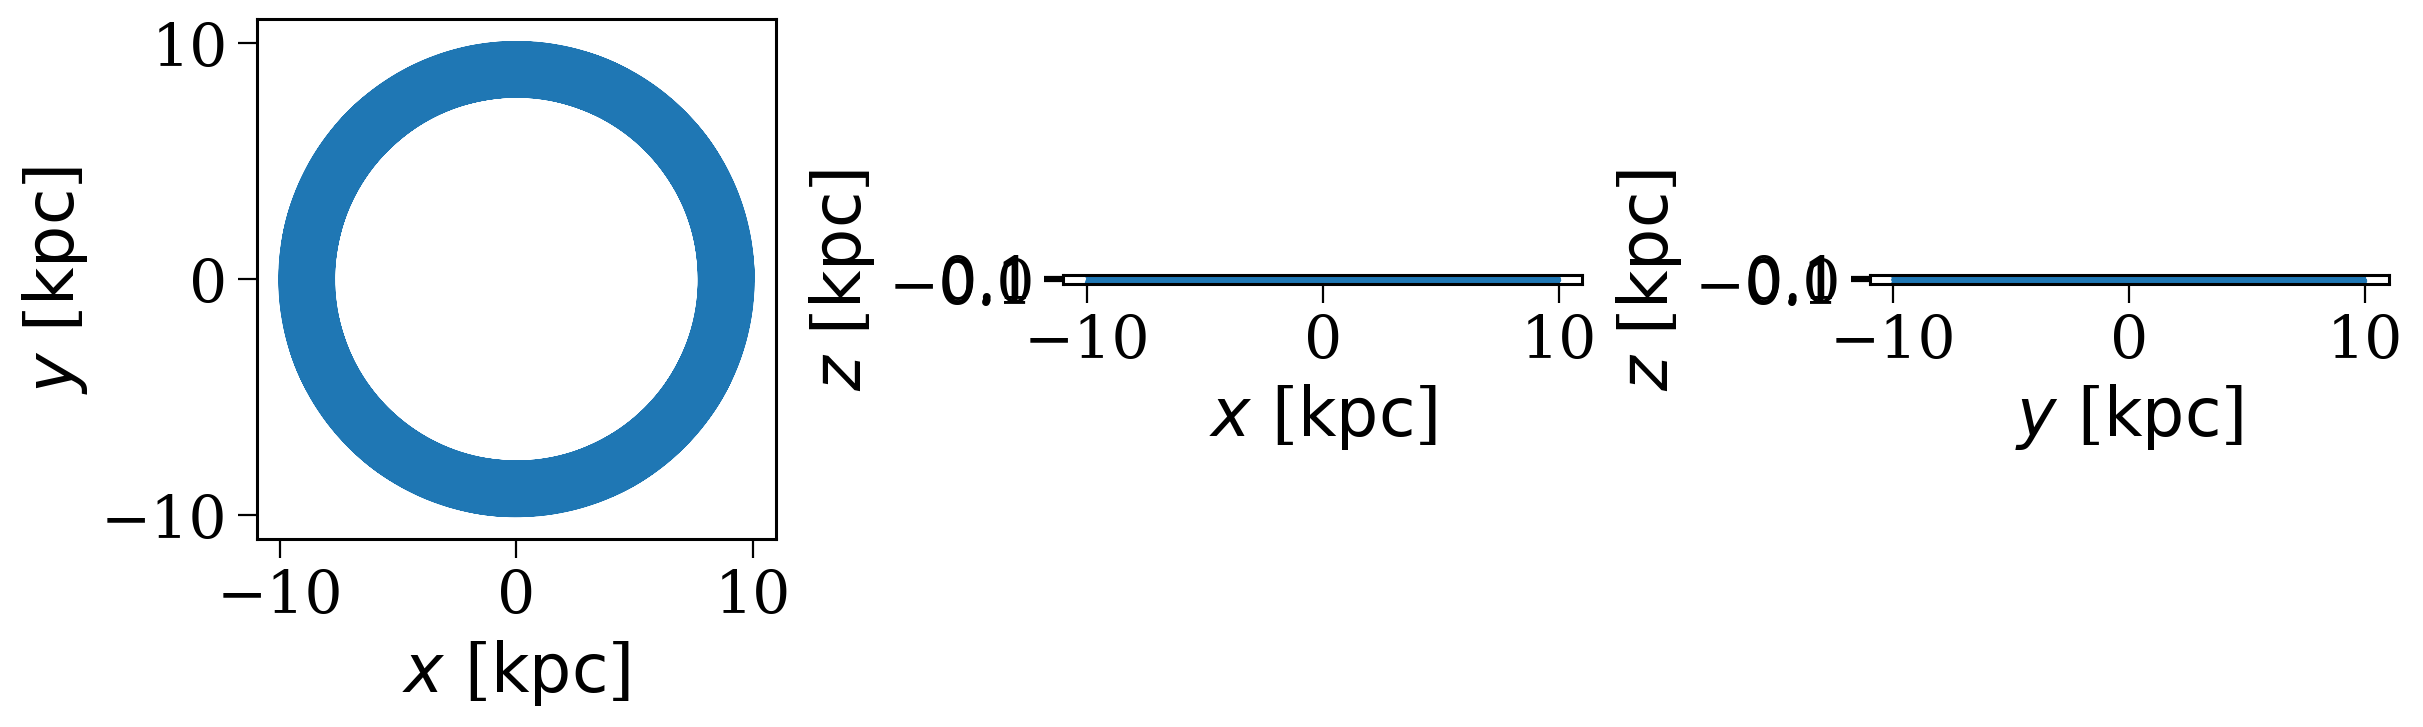

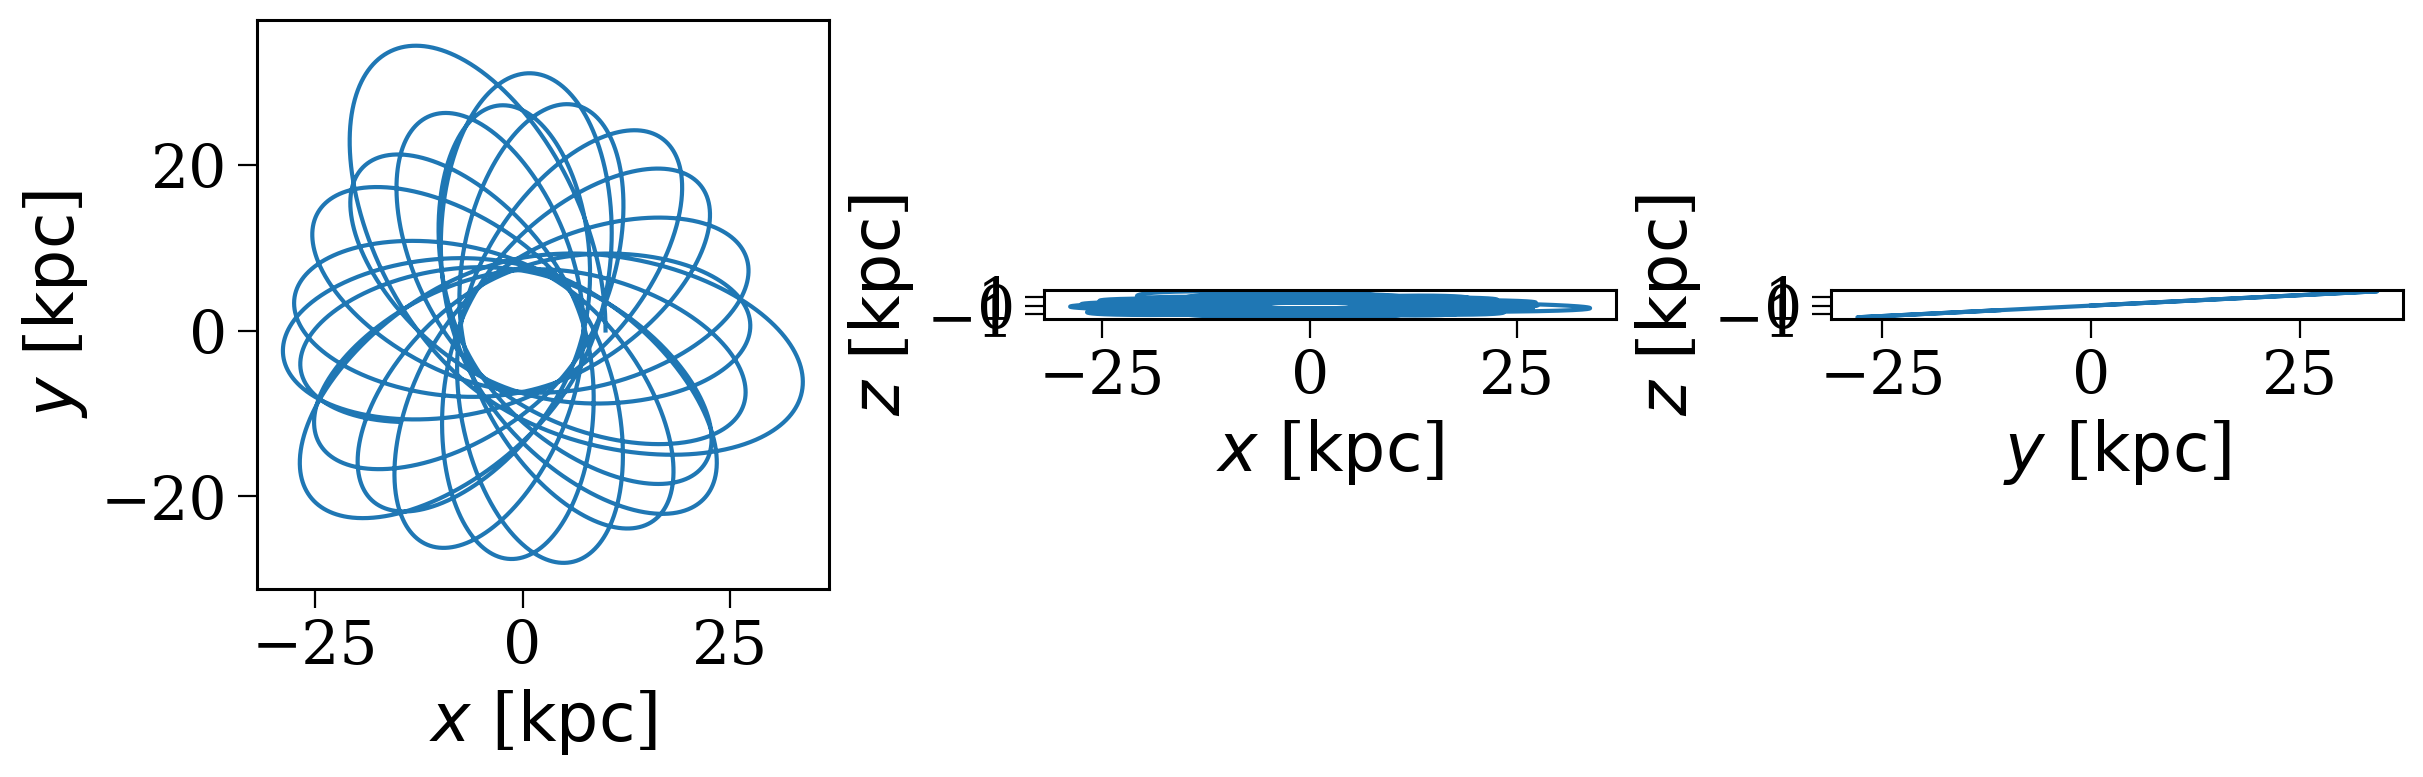

In [48]:
# integrate a test particle orbit in both potentials and compare
import gala.dynamics as gd
w0 = gd.PhaseSpacePosition(pos=[10.0, 0.0, 0.0] * u.kpc, vel=[0, 200.0, 10] * u.km / u.s)
orbit_static = static_mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)
orbit_evolving = evolving_mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)

orbit_static.plot()
plt.show()
orbit_evolving.plot()
plt.show()

In [49]:
from gala.potential.potential.io import to_dict as potential_to_dict, from_dict as potential_from_dict

In [52]:
potential_from_dict(potential_to_dict(evolving_mw))

<CompositePotential disk,bulge,nucleus,halo>

In [91]:
simple = gp.TimeInterpolatedPotential(
    gp.NFWPotential, time_knots, m=mass_at_knot, r_s=15.63 * u.kpc, units="galactic"
)

In [ ]:
import cogsworth

p = cogsworth.pop.Population(10, use_default_BSE_settings=True, processes=2, galactic_potential=simple)
p.create_population()

Run for 10 binaries
Ended up with 13 binaries with m1 > 0 solar masses
[2e-02s] Sample initial binaries
[0.3s] Evolve binaries (run COSMIC)


100%|██████████| 13/13 [00:00<00:00, 1729.56it/s]Process ForkPoolWorker-12:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _Forking

KeyboardInterrupt: 

  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)


  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 365, in get
    res = self._reader.recv_bytes()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
Keybo

In [84]:

redshift_times = cosmo.lookback_time(redshifts).to(u.Gyr)
plot_times = [12, 10, 8, 6, 4, 2, 0] * u.Gyr
closest_indices = [np.argmin(np.abs(redshift_times - pt)) for pt in plot_times]
closest_indices

[np.int64(0),
 np.int64(8),
 np.int64(13),
 np.int64(15),
 np.int64(17),
 np.int64(18),
 np.int64(19)]

Text(0.5, 0, 'Lookback time [Gyr]')

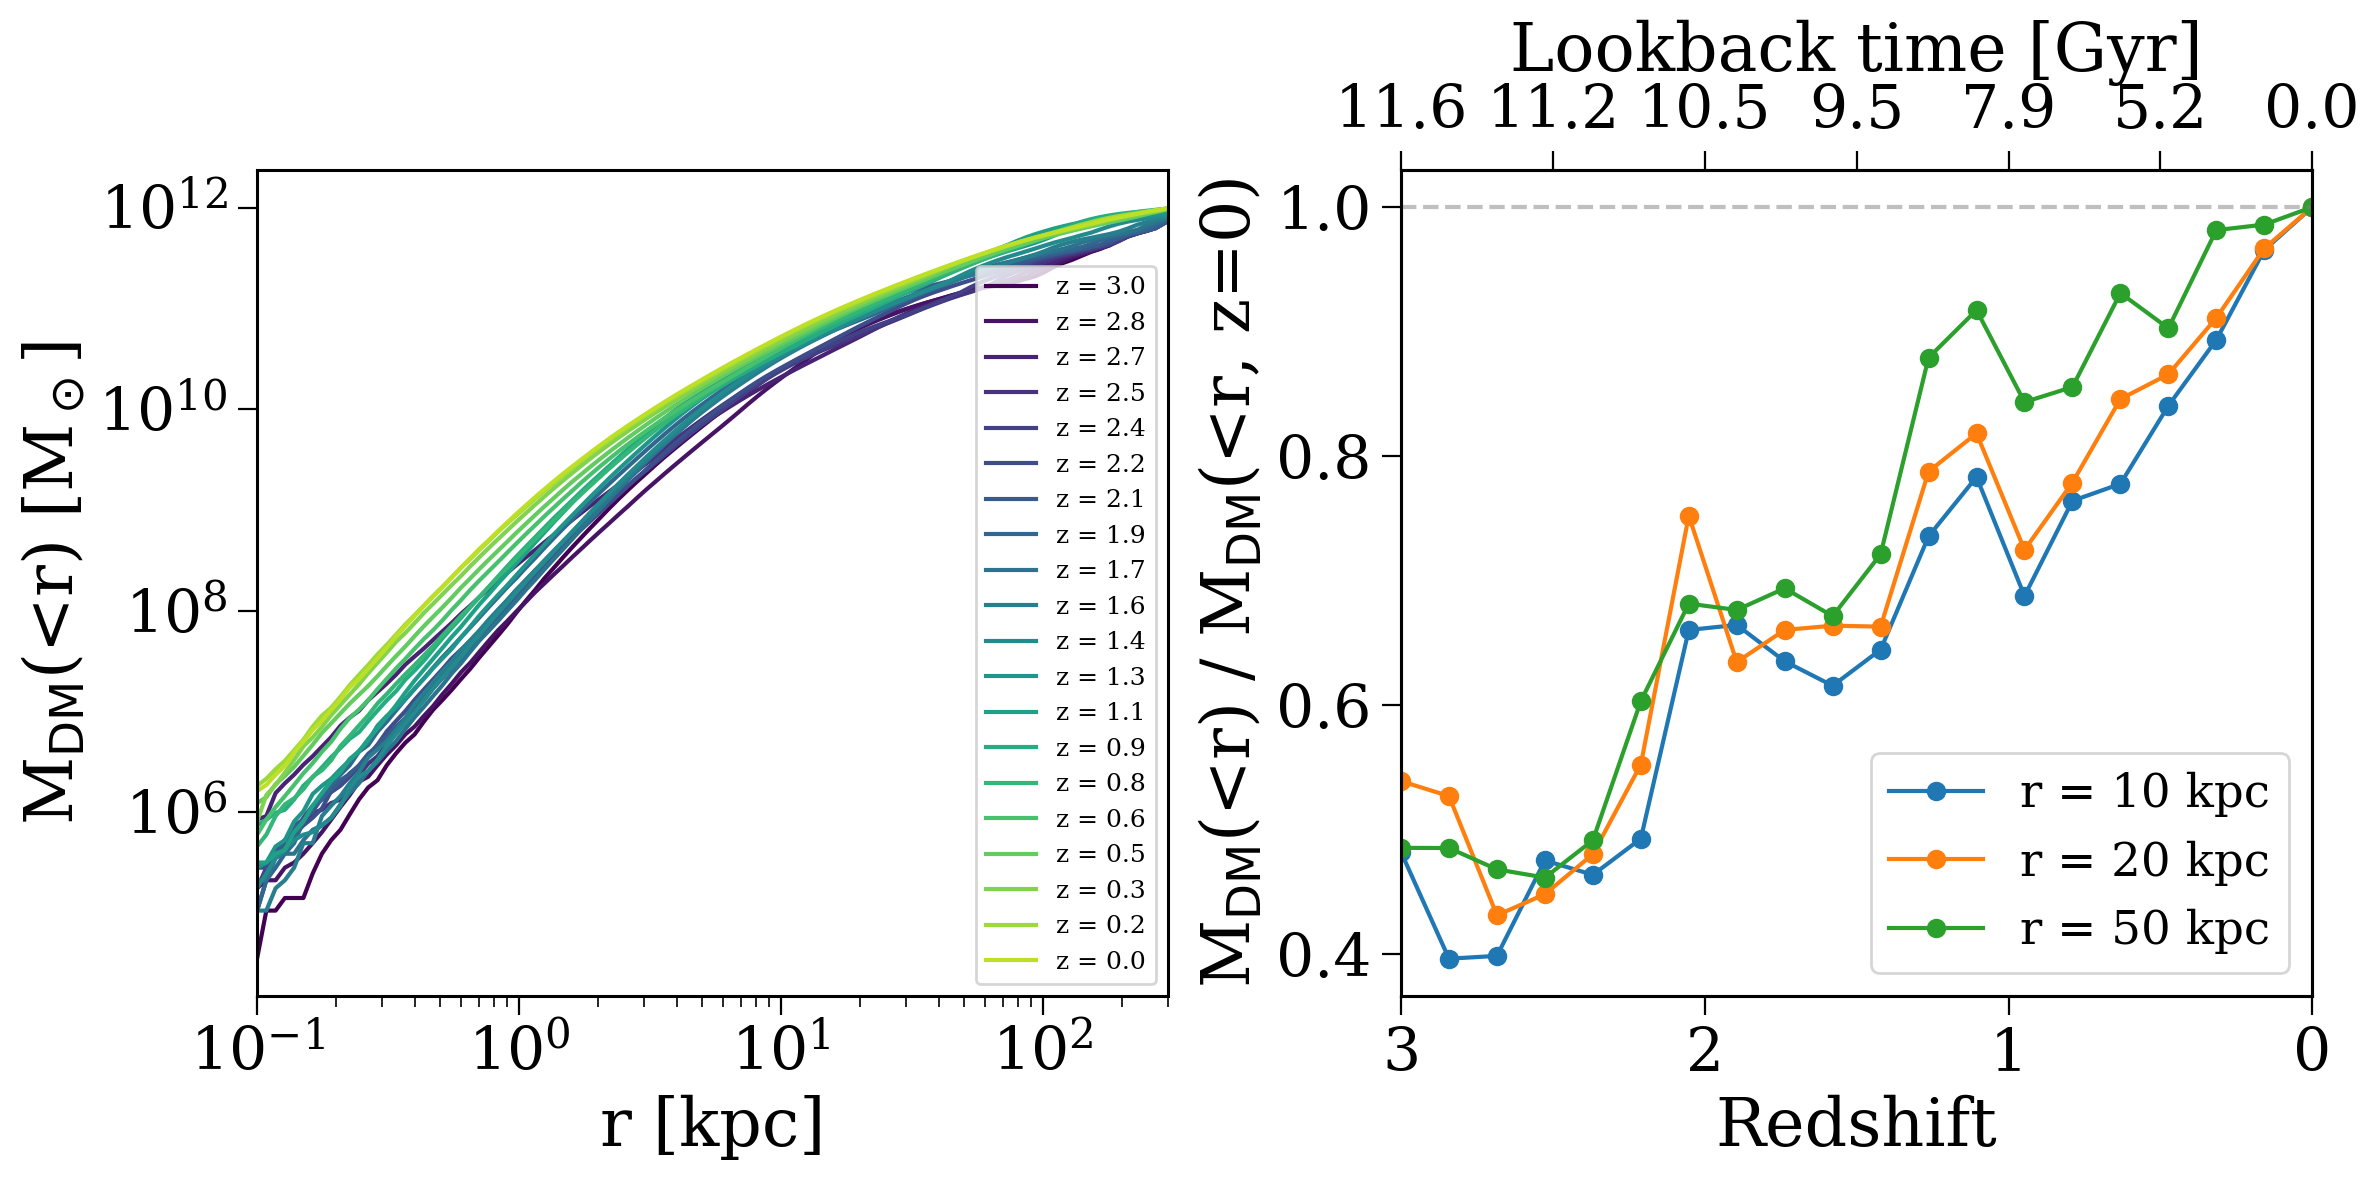

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")

ValueError: x and y must have same first dimension, but have shapes (8,) and (20,)

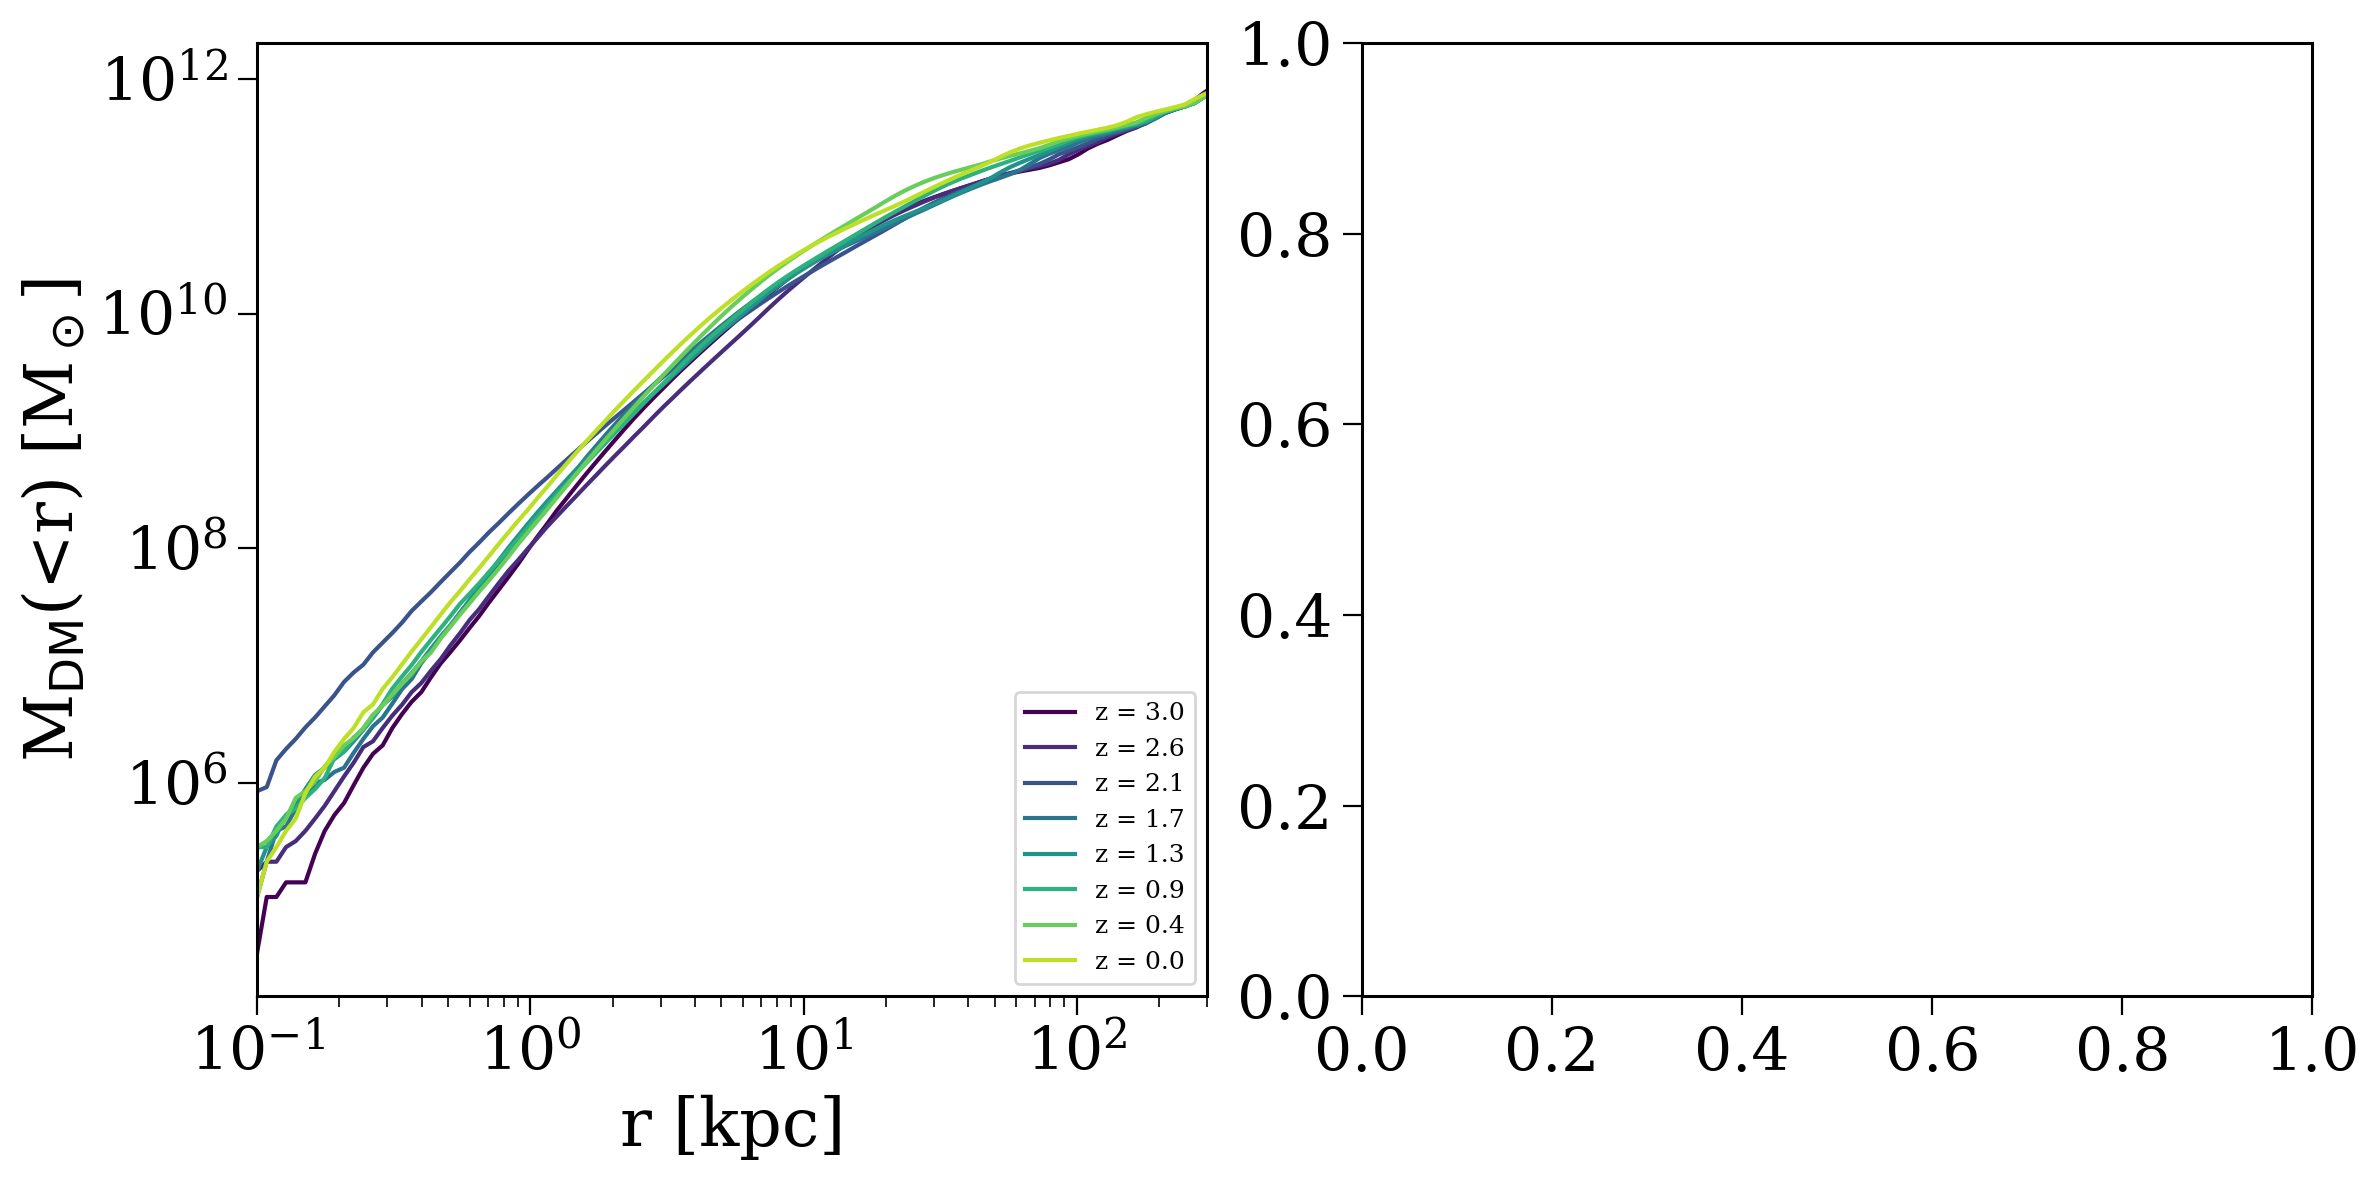

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")